# Recomputing the Köppen ram-pressure criterion for the MAUVE sample — Model E

**Date:** 2026-08-18  
**Scope:** all 40 physical galaxies in the current MAUVE master catalogue  
**Purpose:** reproduce Model C with GoldMine optical diameters, morphologies, and rotation speeds in place of the HyperLeda snapshot, while retaining the Jones et al. (2018) AMIGA initial-mass relation and Wang et al. (2016) initial H I cutoff.

This notebook answers a deliberately narrow question:

> Given the present H I deficit, what stripping pressure is required in the Köppen analytic disk model, and is that pressure larger than the maximum local pressure available at the galaxy's projected Virgo-centric radius?

The key diagnostic is

$$
\mathcal{R}_{\rm RP}=\frac{p_{\rm def}}{p_{\rm loc}},\qquad
\Delta_{\rm RP}=\log_{10}\mathcal{R}_{\rm RP}.
$$

Köppen et al. use a factor-of-two margin: $p_{\rm def}>2p_{\rm loc}$ is evidence that the observed deficit cannot be produced at the current projected position under the most favourable local velocity, and therefore favours **past stripping**. It is not a complete orbital reconstruction and it is not, by itself, a proof of a unique evolutionary history.

## 1. Revised roadmap and what is held fixed

This is **Level 1: controlled reproduction using Model E**.

1. Build one row per physical MAUVE galaxy. `NGC4567` and `NGC4568` remain separate; no combined `NGC4567_8` row is introduced.
2. Read observed $\log M_{\rm HI}$ and infall stage from the live local MAUVE master file.
3. Use a frozen 2026-08-18 GoldMine snapshot for the optical major-axis diameter at 25 B-mag arcsec$^{-2}$, morphology code, inclination, and observed line width.
4. Convert the GoldMine angular $D_{25}$ to a physical optical diameter at the same fixed MAUVE distance used by Model C, then define $R_{\rm opt}=D_{25}/2$.
5. Estimate the initial H I mass with the Jones et al. (2018) AMIGA morphology-dependent relation and calculate
   $\mathrm{DEF}=\log M_{\rm HI,0}-\log M_{\rm HI,obs}$.
6. Infer a galaxy-dependent initial H I diameter using Wang et al. (2016),
   $\log D_{\rm HI,0}=0.506\log M_{\rm HI,0}-3.293$, and set $r_{\max}=D_{\rm HI,0}/2$.
7. Keep the Köppen H I profile shape, disk restoring-force approximation, Virgo ICM beta model, and Virgo dark-matter beta model unchanged.
8. Preserve the continuous pressure ratio and propagate AMIGA, Wang, GoldMine/Köppen, and observational uncertainties with Monte Carlo draws.
9. Compare the result across the MAUVE pre-/close-/post-peak labels without imposing an expected ordering.

### Important scope boundary

This notebook intentionally follows Model C's core $p_{\rm def}/p_{\rm loc}$ workflow and cell layout. The configuration-space proxy $p_{\rm cfg}$ remains a separate extension and is not mixed into this controlled Model-E calculation.

## 2. Provenance ledger

| Quantity | Adopted source in this notebook | Role / caveat |
|---|---|---|
| MAUVE membership, $\log M_{\rm HI,obs}$, LOS velocity, stage | local `mauve_master_wiki_newclass.fits` | The FITS table is the live MAUVE compilation. Its `vel` column is treated as heliocentric, although the header does not document its frame or row-level provenance. It does **not** encode a per-row literature reference or uncertainty for H I mass, so this notebook does not claim that all values originate from one survey. |
| $D_{25}$, morphology, inclination, line width | GoldMine live query, frozen on 2026-08-18 | Embedded below for reproducibility. GoldMine `Aradius` is the optical major-axis diameter at 25 B-mag arcsec$^{-2}$. Its morphology codes follow the simplified VCC scheme documented in the GoldMine glossary. |
| GoldMine rotation speed | GoldMine `WIDTHA` and inclination | $v_{\rm rot}=0.98\,\mathrm{WIDTHA}/(2\sin i)$, the conversion validated by the local Model-A GoldMine/Köppen audit. NGC4394 and NGC4457 have $i=0^\circ$, so their pressure calculation is undefined. |
| GoldMine size/velocity uncertainties | Köppen et al. (2018), cross-catalogue comparison | 0.08 dex in optical size and 15 km s$^{-1}$ in rotation speed are used because GoldMine supplies no row-level formal errors. Morphology is held fixed. |
| Initial H I mass | Jones et al. (2018), AMIGA | Morphology-dependent fit is fiducial; the all-type fit is retained as a sensitivity check. Intrinsic scatter is propagated. |
| Initial H I diameter | Wang et al. (2016) | $D_{\rm HI}$ is defined at $1\,M_\odot\,\mathrm{pc}^{-2}$; the 0.06 dex relation scatter is propagated. |
| Sky coordinates | local `simbad_object_crosswalk.csv` beside this notebook | Frozen SIMBAD cross-match used only for projected separation from M87. |
| Galaxy identity colours | local `MAUVE_galaxy_colors.dat` | Fixed project palette; black is not used for individual galaxies. |
| Virgo/Köppen physics | Köppen et al. (2018) | Held fixed in the controlled reproduction. |

Primary references:

- [Wang et al. 2016, MNRAS 460, 2143](https://academic.oup.com/mnras/article/460/2/2143/2609089)
- [Köppen et al. 2018, MNRAS 479, 4367](https://academic.oup.com/mnras/article/479/4/4367/5040236)
- [Jones et al. 2018, A&A 609, A17](https://www.aanda.org/articles/aa/full_html/2018/01/aa31448-17/aa31448-17.html)
- [GoldMine database](http://goldmine.inaf.it/) and [field glossary](http://goldmine.inaf.it/glossary.html)

The adopted common distance is 16.5 Mpc, consistent with the current MAUVE environmental workflow. It is held fixed rather than sampled because the master H I masses have not been supplied with enough provenance to rescale every row self-consistently with a distance draw.

For M87, this notebook adopts the current [SIMBAD heliocentric radial velocity](https://simbad.cds.unistra.fr/simbad/sim-basic?Ident=M87), $1256\pm36$ km s$^{-1}$.

In [1]:
# Core scientific and display dependencies.
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from astropy.coordinates import SkyCoord
from astropy.table import Table
import astropy.units as u
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:.4g}")

# Reproducibility controls and fixed project choices.
RNG_SEED = 20260815
N_MC = 20_000
DISTANCE_MPC = 16.5
SIGMA_LOG_MHI_OBS_DEX = 0.10
SIGMA_LOG_D25_DEX = 0.08
SIGMA_VROT_KMS = 15.0
SIGMA_LOG_PLOC_DEX = np.log10(2.0)
M87_VLOS_KMS = 1256.0
M87_VLOS_ERR_KMS = 36.0

# Köppen et al. disk parameters.
WANG_SLOPE = 0.506
WANG_INTERCEPT = -3.293
WANG_SCATTER_DEX = 0.06
RESTORING_G = 2.0
STELLAR_BOOST_A = 15.0
R0_AT_ROPT_15_KPC = 2.0  # kpc

# Köppen et al. Virgo ICM and dark-matter beta models.
ICM_N0_CM3 = 0.04
ICM_RC_KPC = 13.4
ICM_BETA = 0.47
DM_RHO0_MSUN_PC3 = 3.8e-4
DM_RC_KPC = 320.0
DM_BETA = 1.0
G_KPC_KMS2_MSUN = 4.30091e-6

# One solar mass of atomic hydrogen spread over one square parsec gives this
# H-atom column; dividing by one kpc converts column/radius to number density.
MSUN_PC2_TO_H_CM2 = 1.2480e20
KPC_TO_CM = 3.0856775814913673e21
SURFACE_OVER_KPC_TO_CM3 = MSUN_PC2_TO_H_CM2 / KPC_TO_CM

HERE = Path.cwd()
MASTER_PATH = HERE / "mauve_master_wiki_newclass.fits"
COLOR_PATH = HERE / "MAUVE_galaxy_colors.dat"
COORD_PATH = HERE / "simbad_object_crosswalk.csv"

print(f"Working directory: {HERE}")
print(f"Monte Carlo draws per galaxy: {N_MC:,}")

Working directory: /Users/Igniz/Desktop/ICRAR/further
Monte Carlo draws per galaxy: 20,000


## 3. Assemble the 40-galaxy analysis table

The joins below are intentionally strict. A missing galaxy, duplicate identifier, or accidental combined-pair name should stop the notebook immediately rather than produce a partially matched result.

The fixed colour file is read independently of catalogue row order. This matters because plotting colours should continue to identify the same physical galaxy after sorting by stage, pressure, or deficiency.

In [2]:
def clean_text(value):
    """Decode byte strings from FITS tables and remove surrounding whitespace."""
    if isinstance(value, (bytes, np.bytes_)):
        value = value.decode("utf-8")
    return str(value).strip()


def read_mauve_colors(path):
    """Read the approved project colour mapping, ignoring its comment header."""
    colors = {}
    with open(path, "r", encoding="utf-8") as handle:
        for line in handle:
            if not line.strip() or line.lstrip().startswith("#"):
                continue
            fields = line.split()
            colors[fields[1]] = fields[3]
    return colors


master = Table.read(MASTER_PATH).to_pandas()
master["Galaxy"] = master["Galaxy"].map(clean_text)
master["stage"] = master["class"].astype(int)
master["stage_label"] = master["stage"].map({1: "pre-peak", 2: "close-to-peak", 3: "post-peak"})

coords = pd.read_csv(COORD_PATH).rename(columns={"component": "Galaxy"})
coords["Galaxy"] = coords["Galaxy"].map(clean_text)

galaxy_colors = read_mauve_colors(COLOR_PATH)

assert len(master) == 40, f"Expected 40 physical MAUVE galaxies, found {len(master)}"
assert master["Galaxy"].is_unique, "The MAUVE master catalogue contains duplicate galaxy IDs"
assert "NGC4567_8" not in set(master["Galaxy"]), "Combined pair ID found in a component-level analysis"
assert set(master["Galaxy"]) == set(coords["Galaxy"]), "SIMBAD cross-match does not match the MAUVE sample"
assert set(master["Galaxy"]).issubset(galaxy_colors), "Fixed colours are missing for one or more galaxies"

sample = master.merge(
    coords[["Galaxy", "main_id", "ra_deg", "dec_deg", "coordinate_bibcode"]],
    on="Galaxy",
    how="left",
    validate="one_to_one",
)
sample["galaxy_color"] = sample["Galaxy"].map(galaxy_colors)

display(sample[["Galaxy", "logMHI", "vel", "stage_label", "main_id", "ra_deg", "dec_deg"]])
print("Strict sample assembly passed: 40 unique component galaxies.")

,Galaxy,logMHI,vel,stage_label,main_id,ra_deg,dec_deg
0,NGC4189,8.78,1995,pre-peak,NGC 4189,183.4,13.42
1,NGC4192,9.655,-118,pre-peak,M 98,183.5,14.9
2,NGC4222,8.832,225,pre-peak,NGC 4222,184.1,13.31
3,NGC4254,9.673,2453,pre-peak,M 99,184.7,14.42
4,NGC4294,9.24,421,pre-peak,NGC 4294,185.3,11.51
5,NGC4321,9.486,1579,pre-peak,M 100,185.7,15.82
6,NGC4351,8.503,2388,pre-peak,NGC 4351,186,12.21
7,NGC4383,9.492,1663,pre-peak,NGC 4383,186.4,16.47
8,NGC4396,8.963,-115,pre-peak,NGC 4396,186.5,15.67
9,NGC4535,9.542,1973,pre-peak,NGC 4535,188.6,8.198


Strict sample assembly passed: 40 unique component galaxies.


## 4. Frozen GoldMine input snapshot

The table below is embedded, rather than queried during execution, so the notebook remains reproducible if the live database changes or is temporarily unavailable.

- `D25_arcsec`: GoldMine `Aradius`, the optical major-axis diameter at 25 B-mag arcsec$^{-2}$.
- `goldmine_type_code`: simplified VCC morphology code documented by GoldMine.
- `WIDTHA_kms`: observed line width used with the GoldMine inclination to reconstruct $v_{\rm rot}$.

For the Jones et al. morphology bins, the GoldMine classes are mapped by their documented labels:

$$
\begin{aligned}
\mathrm{GoldMine}\le4\quad &(\mathrm{E/S0\ through\ Sab}) &&\rightarrow T<3,\\
5\le\mathrm{GoldMine}\le7\quad &(\mathrm{Sb\ through\ Sc}) &&\rightarrow 3\le T\le5,\\
8\le\mathrm{GoldMine}\le12\quad &(\mathrm{Scd\ through\ Im}) &&\rightarrow T>5.
\end{aligned}
$$

NGC4694 has GoldMine code 20 (unclassified), so the Jones all-type relation already retained by Model C is used as an explicit one-row fallback. NGC4064 is the only object not recoverable from the current GoldMine endpoint; its published GoldMine-derived Köppen row supplies $R_{\rm opt}$ and $v_{\rm rot}$, and its SB(s)a morphology is mapped to GoldMine's Sa code 3. NGC4394 and NGC4457 have GoldMine $i=0^\circ$, leaving inclination-corrected $v_{\rm rot}$ undefined.

In [3]:
GOLDMINE_CSV = """Galaxy,VCC,D25_arcsec,goldmine_type_code,inclination_deg,WIDTHA_kms,vrot_kms,input_status
NGC4189,89,135.6,7.0,43.865,254.0,179.605927517,live GoldMine exact positional match 2026-08-18
NGC4192,92,586.8,5.0,74.62,462.0,234.788226075,live GoldMine exact positional match 2026-08-18
NGC4222,187,211.2,8.0,81.875,226.0,111.862870126,live GoldMine exact positional match 2026-08-18
NGC4254,307,369.0,7.0,24.428,229.0,271.333952752,live GoldMine exact positional match 2026-08-18
NGC4294,465,237.0,7.0,71.74,196.0,101.132586581,live GoldMine exact positional match 2026-08-18
NGC4321,596,547.2,7.0,27.234,251.0,268.756796160,live GoldMine exact positional match 2026-08-18
NGC4351,692,175.2,7.0,50.203,95.0,60.586968219,live GoldMine exact positional match 2026-08-18
NGC4383,801,156.0,3.0,60.285,219.0,123.557606012,live GoldMine exact positional match 2026-08-18
NGC4396,865,201.6,7.0,72.722,193.0,99.039150286,live GoldMine exact positional match 2026-08-18
NGC4535,1555,499.8,7.0,26.893,275.0,297.904771751,live GoldMine exact positional match 2026-08-18
NGC4567,1673,175.2,7.0,50.203,214.0,136.480117882,live GoldMine exact positional match 2026-08-18
NGC4568,1676,306.0,7.0,69.967,341.0,177.850776680,live GoldMine exact positional match 2026-08-18
NGC4298,483,216.0,7.0,56.088,252.0,148.789825934,live GoldMine exact positional match 2026-08-18
NGC4302,497,404.4,7.0,76.306,372.0,187.613105850,live GoldMine exact positional match 2026-08-18
NGC4330,630,351.6,9.0,75.712,241.0,121.859423753,live GoldMine exact positional match 2026-08-18
NGC4388,836,306.0,4.0,75.967,361.0,182.331458412,live GoldMine exact positional match 2026-08-18
NGC4402,873,237.0,7.0,72.959,239.0,122.487790385,live GoldMine exact positional match 2026-08-18
NGC4424,979,259.8,3.0,60.107,61.0,34.476886153,live GoldMine exact positional match 2026-08-18
NGC4501,1401,433.8,6.0,57.761,511.0,296.028664364,live GoldMine exact positional match 2026-08-18
NGC4522,1516,242.4,6.0,75.707,209.0,105.681268468,live GoldMine exact positional match 2026-08-18
NGC4654,1987,299.4,7.0,58.628,289.0,165.857483621,live GoldMine exact positional match 2026-08-18
NGC4694,2066,192.0,20.0,68.781,66.0,34.691983593,live GoldMine exact positional match 2026-08-18
NGC4064,,276.637505,3,,,58.8,Koppen2018 Appendix E GoldMine-derived row; D25 reconstructed from Ropt at 17 Mpc; SB(s)a mapped to GoldMine Sa code 3
NGC4216,167,547.2,5.0,76.338,517.0,260.706432140,live GoldMine exact positional match 2026-08-18
NGC4293,460,306.0,3.0,55.1,274.0,163.701387450,live GoldMine exact positional match 2026-08-18
NGC4380,792,211.2,4.0,60.218,268.0,151.303999291,live GoldMine exact positional match 2026-08-18
NGC4394,857,216.0,5.0,0.0,174.0,,live GoldMine exact match; inclination=0 so vrot undefined
NGC4405,874,113.4,7.0,54.062,169.0,102.278438350,live GoldMine exact positional match 2026-08-18
NGC4419,958,211.2,3.0,66.775,187.0,99.710177545,live GoldMine exact positional match 2026-08-18
NGC4450,1110,369.0,4.0,48.96,319.0,207.238599746,live GoldMine exact positional match 2026-08-18
IC3392,1126,175.2,7.0,66.627,208.0,111.031019444,live GoldMine exact positional match 2026-08-18
NGC4457,1145,175.2,5.0,0.0,172.0,,live GoldMine exact match; inclination=0 so vrot undefined
NGC4548,1615,360.0,5.0,33.747,234.0,206.398721609,live GoldMine exact positional match 2026-08-18
NGC4569,1690,643.8,4.0,60.123,382.0,215.869789004,live GoldMine exact positional match 2026-08-18
NGC4579,1727,377.4,3.0,39.283,360.0,278.606418769,live GoldMine exact positional match 2026-08-18
NGC4580,1730,129.6,7.0,42.227,190.0,138.527316995,live GoldMine exact positional match 2026-08-18
NGC4606,1859,306.0,3.0,66.823,144.0,76.754602745,live GoldMine exact positional match 2026-08-18
NGC4607,1868,237.0,8.0,78.651,183.0,91.458309514,live GoldMine exact positional match 2026-08-18
NGC4689,2058,351.6,7.0,40.761,183.0,137.340003431,live GoldMine exact positional match 2026-08-18
NGC4698,2070,340.2,3.0,59.972,418.0,236.572540648,live GoldMine exact positional match 2026-08-18
"""

goldmine = pd.read_csv(StringIO(GOLDMINE_CSV))
assert len(goldmine) == 40 and goldmine["Galaxy"].is_unique
assert set(sample["Galaxy"]) == set(goldmine["Galaxy"]), "GoldMine snapshot/sample mismatch"

sample = sample.merge(goldmine, on="Galaxy", how="left", validate="one_to_one")
assert sample[["D25_arcsec", "goldmine_type_code"]].notna().all().all()
assert set(sample.loc[~np.isfinite(sample["vrot_kms"]), "Galaxy"]) == {"NGC4394", "NGC4457"}
assert (sample.loc[np.isfinite(sample["vrot_kms"]), "vrot_kms"] > 0).all()

sample["vrot"] = sample["vrot_kms"]
sample["vrot_uncertainty_kms"] = np.where(np.isfinite(sample["vrot"]), SIGMA_VROT_KMS, np.nan)

display(sample[[
    "Galaxy", "VCC", "D25_arcsec", "goldmine_type_code", "inclination_deg",
    "WIDTHA_kms", "vrot", "vrot_uncertainty_kms", "input_status",
]])
print("GoldMine D25 and morphology coverage: 40/40.")
print("GoldMine pressure-ready rotation coverage: 38/40.")
print("Undefined inclination-corrected vrot: NGC4394, NGC4457")

,Galaxy,VCC,D25_arcsec,goldmine_type_code,inclination_deg,WIDTHA_kms,vrot,vrot_uncertainty_kms,input_status
0,NGC4189,89,135.6,7,43.87,254,179.6,15,live GoldMine exact positional match 2026-08-18
1,NGC4192,92,586.8,5,74.62,462,234.8,15,live GoldMine exact positional match 2026-08-18
2,NGC4222,187,211.2,8,81.88,226,111.9,15,live GoldMine exact positional match 2026-08-18
3,NGC4254,307,369,7,24.43,229,271.3,15,live GoldMine exact positional match 2026-08-18
4,NGC4294,465,237,7,71.74,196,101.1,15,live GoldMine exact positional match 2026-08-18
5,NGC4321,596,547.2,7,27.23,251,268.8,15,live GoldMine exact positional match 2026-08-18
6,NGC4351,692,175.2,7,50.2,95,60.59,15,live GoldMine exact positional match 2026-08-18
7,NGC4383,801,156,3,60.28,219,123.6,15,live GoldMine exact positional match 2026-08-18
8,NGC4396,865,201.6,7,72.72,193,99.04,15,live GoldMine exact positional match 2026-08-18
9,NGC4535,1555,499.8,7,26.89,275,297.9,15,live GoldMine exact positional match 2026-08-18


GoldMine D25 and morphology coverage: 40/40.
GoldMine pressure-ready rotation coverage: 38/40.
Undefined inclination-corrected vrot: NGC4394, NGC4457


## 5. Optical diameter and the AMIGA expected-H I calibration

GoldMine's `Aradius` is used as the angular major-axis diameter $D_{25}$ in arcseconds. Model E retains Model C's fixed 16.5 Mpc MAUVE distance for the angular-to-physical conversion and defines $R_{\rm opt}=D_{25}/2$.

The fiducial Jones et al. (2018) relation is

$$
\log M_{\rm HI,exp}=A_T\,[2\log D_{25}(\mathrm{kpc})]+B_T,
$$

with $(A_T,B_T,\sigma_{\rm int})=(1.04,6.44,0.27)$ for $T<3$,
$(0.93,7.14,0.16)$ for $3\le T\le5$, and $(0.81,7.53,0.17)$ for $T>5$.
GoldMine's morphology labels are mapped to these three bins as documented above. Its code 20 is unclassified, so NGC4694 uses the Jones all-type fallback

$$
\log M_{\rm HI,exp,all}=1.72\log D_{25}(\mathrm{kpc})+7.30
$$

with 0.21 dex intrinsic scatter. The all-type value is retained for every galaxy as the same calibration-sensitivity comparison used by Model C.

Model E otherwise retains Model C's Wang et al. (2016) initial-diameter prescription:

$$
\log_{10}\left(\frac{{D_{{\rm HI,0}}}}{{\mathrm{{kpc}}}}\right)
=0.506\log_{10}\left(\frac{{M_{{\rm HI,0}}}}{{M_\odot}}\right)-3.293,
\qquad r_{{\max}}=\frac{{D_{{\rm HI,0}}}}2.
$$

In [4]:
def angular_diameter_kpc_from_arcsec(d25_arcsec, distance_mpc=DISTANCE_MPC):
    """Convert angular major-axis diameter in arcseconds to physical kpc."""
    return np.deg2rad(np.asarray(d25_arcsec, dtype=float) / 3_600.0) * distance_mpc * 1_000.0


def amiga_parameters_goldmine(type_code):
    """Map documented GoldMine morphology labels into the three Jones+2018 bins."""
    type_code = np.asarray(type_code, dtype=float)
    early = (type_code >= 0) & (type_code <= 4)
    intermediate = (type_code >= 5) & (type_code <= 7)
    late = (type_code >= 8) & (type_code <= 12)
    a = np.select([early, intermediate, late], [1.04, 0.93, 0.81], default=np.nan)
    b = np.select([early, intermediate, late], [6.44, 7.14, 7.53], default=np.nan)
    scatter = np.select([early, intermediate, late], [0.27, 0.16, 0.17], default=np.nan)
    label = np.select(
        [early, intermediate, late],
        ["GoldMine E/S0-Sab -> Jones T<3", "GoldMine Sb-Sc -> Jones 3<=T<=5", "GoldMine Scd-Im -> Jones T>5"],
        default="GoldMine unclassified -> Jones all-type fallback",
    )
    return a, b, scatter, label


sample["D25_arcmin"] = sample["D25_arcsec"] / 60.0
sample["D25_kpc"] = angular_diameter_kpc_from_arcsec(sample["D25_arcsec"])
sample["Ropt_kpc"] = 0.5 * sample["D25_kpc"]

a_t, b_t, scatter_t, relation_label = amiga_parameters_goldmine(sample["goldmine_type_code"])
sample["amiga_A"] = a_t
sample["amiga_B"] = b_t
sample["amiga_scatter_dex"] = scatter_t
sample["amiga_relation_source"] = relation_label
sample["logMHI_exp_morph"] = a_t * (2.0 * np.log10(sample["D25_kpc"])) + b_t
sample["logMHI_exp_all"] = 1.72 * np.log10(sample["D25_kpc"]) + 7.30
use_all_type_fallback = ~np.isfinite(sample["logMHI_exp_morph"])
assert set(sample.loc[use_all_type_fallback, "Galaxy"]) == {"NGC4694"}
sample["logMHI_exp"] = np.where(
    use_all_type_fallback, sample["logMHI_exp_all"], sample["logMHI_exp_morph"]
)
sample["amiga_scatter_dex"] = np.where(use_all_type_fallback, 0.21, sample["amiga_scatter_dex"])
sample["DEF"] = sample["logMHI_exp"] - sample["logMHI"]
sample["DEF_all"] = sample["logMHI_exp_all"] - sample["logMHI"]
sample["DHI0_Wang_kpc"] = 10.0 ** (WANG_SLOPE * sample["logMHI_exp"] + WANG_INTERCEPT)
sample["rmax_kpc"] = 0.5 * sample["DHI0_Wang_kpc"]
sample["rmax_over_Ropt"] = sample["rmax_kpc"] / sample["Ropt_kpc"]
sample["goldmine_applicability_note"] = np.where(
    sample["Galaxy"] == "NGC4064",
    "current GoldMine endpoint missing; K18 GoldMine-derived reconstruction",
    np.where(use_all_type_fallback, "GoldMine type 20: Jones all-type fallback", "GoldMine morphology-bin mapping"),
)

display(sample[[
    "Galaxy", "stage_label", "goldmine_type_code", "D25_arcmin", "D25_kpc", "Ropt_kpc",
    "logMHI", "logMHI_exp", "DEF", "DEF_all", "DHI0_Wang_kpc", "rmax_kpc",
    "rmax_over_Ropt", "amiga_scatter_dex", "amiga_relation_source",
    "goldmine_applicability_note",
]])

,Galaxy,stage_label,goldmine_type_code,D25_arcmin,D25_kpc,Ropt_kpc,logMHI,logMHI_exp,DEF,DEF_all,DHI0_Wang_kpc,rmax_kpc,rmax_over_Ropt,amiga_scatter_dex,amiga_relation_source,goldmine_applicability_note
0,NGC4189,pre-peak,7,2.26,10.85,5.424,8.78,9.066,0.2854,0.3005,19.69,9.845,1.815,0.16,GoldMine Sb-Sc -> Jones 3<=T<=5,GoldMine morphology-bin mapping
1,NGC4192,pre-peak,5,9.78,46.94,23.47,9.655,10.25,0.5937,0.5197,78.17,39.08,1.665,0.16,GoldMine Sb-Sc -> Jones 3<=T<=5,GoldMine morphology-bin mapping
2,NGC4222,pre-peak,8,3.52,16.89,8.447,8.832,9.519,0.6869,0.5797,33.39,16.69,1.976,0.17,GoldMine Scd-Im -> Jones T>5,GoldMine morphology-bin mapping
3,NGC4254,pre-peak,7,6.15,29.52,14.76,9.673,9.874,0.2014,0.1556,50.52,25.26,1.711,0.16,GoldMine Sb-Sc -> Jones 3<=T<=5,GoldMine morphology-bin mapping
4,NGC4294,pre-peak,7,3.95,18.96,9.479,9.24,9.517,0.2769,0.258,33.3,16.65,1.757,0.16,GoldMine Sb-Sc -> Jones 3<=T<=5,GoldMine morphology-bin mapping
5,NGC4321,pre-peak,7,9.12,43.77,21.89,9.486,10.19,0.7069,0.6371,73.19,36.6,1.672,0.16,GoldMine Sb-Sc -> Jones 3<=T<=5,GoldMine morphology-bin mapping
6,NGC4351,pre-peak,7,2.92,14.01,7.007,8.503,9.273,0.77,0.7695,25.06,12.53,1.788,0.16,GoldMine Sb-Sc -> Jones 3<=T<=5,GoldMine morphology-bin mapping
7,NGC4383,pre-peak,3,2.6,12.48,6.24,9.492,8.72,-0.7717,-0.3064,13.16,6.581,1.055,0.27,GoldMine E/S0-Sab -> Jones T<3,GoldMine morphology-bin mapping
8,NGC4396,pre-peak,7,3.36,16.13,8.063,8.963,9.386,0.4233,0.4142,28.6,14.3,1.773,0.16,GoldMine Sb-Sc -> Jones 3<=T<=5,GoldMine morphology-bin mapping
9,NGC4535,pre-peak,7,8.33,39.98,19.99,9.542,10.12,0.5772,0.5129,67.21,33.61,1.681,0.16,GoldMine Sb-Sc -> Jones 3<=T<=5,GoldMine morphology-bin mapping


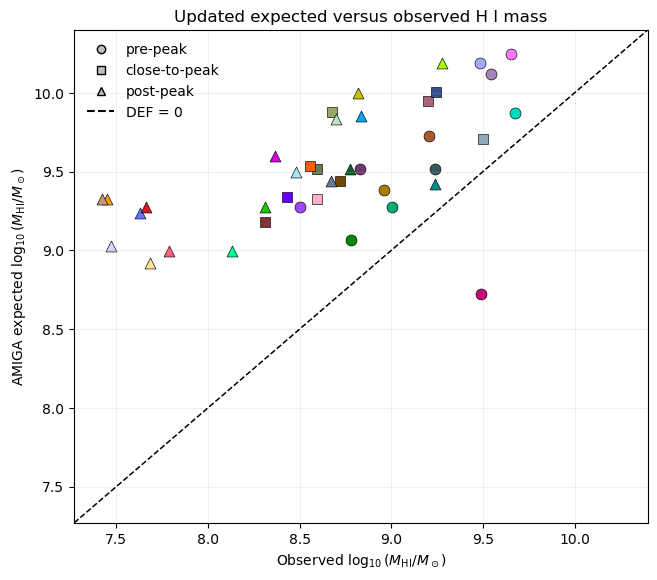

Central-input negative DEF galaxies (1): NGC4383


,Galaxy,stage_label,logMHI,logMHI_exp,DEF
7,NGC4383,pre-peak,9.492,8.72,-0.7717


In [5]:
# First diagnostic: where the updated expected masses sit relative to the observed compilation.
stage_markers = {1: "o", 2: "s", 3: "^"}
stage_labels = {1: "pre-peak", 2: "close-to-peak", 3: "post-peak"}

fig, ax = plt.subplots(figsize=(7.4, 6.4))
for _, row in sample.iterrows():
    ax.scatter(
        row["logMHI"], row["logMHI_exp"],
        marker=stage_markers[row["stage"]], s=62,
        color=row["galaxy_color"], edgecolor="black", linewidth=0.45,
    )

limits = [min(sample["logMHI"].min(), sample["logMHI_exp"].min()) - 0.15,
          max(sample["logMHI"].max(), sample["logMHI_exp"].max()) + 0.15]
ax.plot(limits, limits, color="black", linestyle="--", linewidth=1.1, label="DEF = 0")
ax.set(xlim=limits, ylim=limits,
       xlabel=r"Observed $\log_{10}(M_{\rm HI}/M_\odot)$",
       ylabel=r"AMIGA expected $\log_{10}(M_{\rm HI}/M_\odot)$")
ax.grid(alpha=0.2)
handles = [Line2D([], [], marker=stage_markers[s], linestyle="None", color="0.35",
                  markerfacecolor="0.75", markeredgecolor="black", label=stage_labels[s])
           for s in (1, 2, 3)]
handles.append(Line2D([], [], color="black", linestyle="--", label="DEF = 0"))
ax.legend(handles=handles, frameon=False)
ax.set_title("Updated expected versus observed H I mass")
plt.show()

# Report the central-input negative deficiencies explicitly. These are not
# forced to DEF=0 and will not receive a deterministic stripping inversion.
negative_deficiency = sample.loc[
    sample["DEF"] < 0,
    ["Galaxy", "stage_label", "logMHI", "logMHI_exp", "DEF"],
].sort_values("DEF")
print(
    f"Central-input negative DEF galaxies ({len(negative_deficiency)}): "
    + ", ".join(negative_deficiency["Galaxy"])
)
display(negative_deficiency)

## 6. Invert H I deficiency to a Model-E stripping radius

Köppen et al. adopt the initial H I surface-density shape

$$
\Sigma_{\rm HI}(r)=\frac{\Sigma_0}{[1+(r/R)^2]^{3/2}},
\qquad R=R_{\rm opt}.
$$

Model E keeps this shape and Model C's galaxy-dependent Wang cutoff $r_{\max}=D_{\rm HI,0}/2$. Normalizing to the AMIGA initial mass $M_0$ gives

$$
\Sigma_0=\frac{M_0}{2\pi R^2 C},\qquad
C=1-\left[1+(r_{\max}/R)^2\right]^{-1/2}.
$$

If all gas outside $r_{\rm strip}$ is removed, the remaining mass fraction is $10^{-\mathrm{DEF}}$. Analytic inversion gives

$$
A=1-C10^{-\mathrm{DEF}},\qquad
r_{\rm strip}=R\sqrt{A^{-2}-1}.
$$

Unlike the earlier notebook, $C$ is recalculated for every galaxy and every Monte Carlo draw. For $\mathrm{DEF}\le0$, the stripping interpretation has no physical missing-H I mass to invert. Those cases are retained but assigned `NaN` for $r_{\rm strip}$ and $p_{\rm def}$; they are never clipped to zero deficiency.

In [6]:
def profile_integral_factor(ropt_kpc, rmax_kpc):
    """Dimensionless mass integral for the truncated Köppen H I profile."""
    ropt_kpc, rmax_kpc = np.broadcast_arrays(
        np.asarray(ropt_kpc, dtype=float), np.asarray(rmax_kpc, dtype=float)
    )
    return 1.0 - 1.0 / np.sqrt(1.0 + (rmax_kpc / ropt_kpc) ** 2)


def stripping_radius_kpc(deficiency, ropt_kpc, rmax_kpc):
    """Analytic radius enclosing 10**(-DEF) of a disk truncated at rmax."""
    deficiency, ropt_kpc, rmax_kpc = np.broadcast_arrays(
        np.asarray(deficiency, dtype=float),
        np.asarray(ropt_kpc, dtype=float),
        np.asarray(rmax_kpc, dtype=float),
    )
    result = np.full(deficiency.shape, np.nan, dtype=float)
    valid = (deficiency > 0.0) & (ropt_kpc > 0.0) & (rmax_kpc > 0.0)
    c_profile = profile_integral_factor(ropt_kpc[valid], rmax_kpc[valid])
    a_term = 1.0 - c_profile * np.power(10.0, -deficiency[valid])
    result[valid] = ropt_kpc[valid] * np.sqrt(np.power(a_term, -2.0) - 1.0)
    return result


def sigma_hi_msun_pc2(r_kpc, ropt_kpc, log_mhi_initial, rmax_kpc):
    """Model-E initial-profile H I surface density evaluated at radius r."""
    r_kpc, ropt_kpc, log_mhi_initial, rmax_kpc = np.broadcast_arrays(
        np.asarray(r_kpc, dtype=float),
        np.asarray(ropt_kpc, dtype=float),
        np.asarray(log_mhi_initial, dtype=float),
        np.asarray(rmax_kpc, dtype=float),
    )
    c_profile = profile_integral_factor(ropt_kpc, rmax_kpc)
    mhi_initial = np.power(10.0, log_mhi_initial)
    sigma0 = mhi_initial / (2.0 * np.pi * (ropt_kpc * 1_000.0) ** 2 * c_profile)
    return sigma0 / np.power(1.0 + (r_kpc / ropt_kpc) ** 2, 1.5)


def required_pressure(deficiency, ropt_kpc, log_mhi_initial, rmax_kpc, vrot_kms):
    """Model-E Köppen p_def in units of 10^3 cm^-3 (km/s)^2."""
    r_strip = stripping_radius_kpc(deficiency, ropt_kpc, rmax_kpc)
    sigma_at_strip = sigma_hi_msun_pc2(r_strip, ropt_kpc, log_mhi_initial, rmax_kpc)
    r0_kpc = R0_AT_ROPT_15_KPC * np.asarray(ropt_kpc) / 15.0
    stellar_boost = 1.0 + STELLAR_BOOST_A * np.exp(-r_strip / r0_kpc)
    p_native = (
        sigma_at_strip
        * np.asarray(vrot_kms) ** 2
        / (RESTORING_G * r_strip)
        * stellar_boost
        * SURFACE_OVER_KPC_TO_CM3
    )
    return p_native / 1_000.0


# Limiting checks for several different galaxy-dependent cutoffs.
for test_cutoff in (1.2, 1.5, 2.5, 4.0):
    test_def = np.array([1e-8, 0.1, 0.5, 1.0, 2.0])
    test_r = stripping_radius_kpc(test_def, np.ones_like(test_def), test_cutoff)
    assert np.isclose(test_r[0], test_cutoff, rtol=1e-6)
    assert np.all(np.diff(test_r) < 0)
assert np.isnan(stripping_radius_kpc(np.array([-0.1, 0.0]), 1.0, 1.5)).all()

# Numerical mass-integration check for the generalized normalization.
r_grid = np.linspace(0.0, 12.0, 200_001)
sigma_grid = sigma_hi_msun_pc2(r_grid, 5.0, 9.5, 12.0)
integrated_mass = np.trapezoid(2.0 * np.pi * (1_000.0 * r_grid) * sigma_grid * 1_000.0, r_grid)
assert np.isclose(integrated_mass, 10.0 ** 9.5, rtol=2e-5)
print("Model-E analytic inversion and profile-normalization checks passed.")

Model-E analytic inversion and profile-normalization checks passed.


## 7. Revised local pressure at projected Virgo-centric radius

The ICM number-density profile remains

$$
n_{\rm ICM}(R)=0.04\left[1+\left(\frac{R}{13.4\,\mathrm{kpc}}\right)^2\right]^{-3(0.47)/2}
\ \mathrm{cm}^{-3}.
$$

For the Köppen dark-matter beta model,

$$
v_{\rm esc}^2(r)=8\pi G\rho_0R_c^2
\frac{\operatorname{asinh}(r/R_c)}{r/R_c}.
$$

In addition to this escape-speed ceiling, we now calculate the directly observed LOS difference from M87:

$$
v_{\rm relative,LOS}=|v_{\rm LOS}-v_{\rm M87}|,
\qquad v_{\rm M87}=1256\pm36\ {\rm km\,s^{-1}},
$$

using SIMBAD's current heliocentric M87 value and the local MAUVE master-table `vel` column. The adopted speed and pressure are

$$
v_{\rm upper}=\max(v_{\rm esc},v_{\rm relative,LOS}),
\qquad p_{\rm loc}=n_{\rm ICM}(R_{\rm proj})v_{\rm upper}^2.
$$

`p_loc_escape_only` is also retained to reproduce the original Köppen prescription. The terminology needs care: $v_{\rm relative,LOS}$ is a lower bound on the unknown 3D relative speed, whereas $v_{\rm esc}$ is an upper bound only for a bound orbit. Therefore `v_upper` is a conservative adopted comparison speed, not a strict dynamical upper limit when the LOS term is larger. Such cases are explicitly labelled `LOS relative velocity`.

The master FITS header does not record a velocity frame or per-row provenance for `vel`; the heliocentric interpretation is an explicit working assumption. The Monte Carlo samples the $36\ {\rm km\,s^{-1}}$ M87 uncertainty and the existing factor-of-two $p_{\rm loc}$ model uncertainty.

In [7]:
M87 = SkyCoord("12h30m49.42338s", "+12d23m28.0439s", frame="icrs")


def escape_speed_squared_kms2(radius_kpc):
    """Analytic escape-speed squared for the Köppen beta_DM=1 halo."""
    radius_kpc = np.asarray(radius_kpc, dtype=float)
    x = radius_kpc / DM_RC_KPC
    shape = np.ones_like(x)
    nonzero = x != 0
    shape[nonzero] = np.arcsinh(x[nonzero]) / x[nonzero]
    rho0_msun_kpc3 = DM_RHO0_MSUN_PC3 * 1.0e9
    return 8.0 * np.pi * G_KPC_KMS2_MSUN * rho0_msun_kpc3 * DM_RC_KPC**2 * shape


def icm_number_density_cm3(radius_mpc):
    """Köppen Virgo ICM number density at projected radius."""
    radius_kpc = np.asarray(radius_mpc, dtype=float) * 1_000.0
    return ICM_N0_CM3 * np.power(
        1.0 + (radius_kpc / ICM_RC_KPC)**2, -1.5 * ICM_BETA
    )


def local_pressure(radius_mpc, velocity_kms=None):
    """p_loc in 10^3 cm^-3 (km/s)^2; default velocity is Köppen v_esc."""
    radius_kpc = np.asarray(radius_mpc, dtype=float) * 1_000.0
    if velocity_kms is None:
        velocity_kms = np.sqrt(escape_speed_squared_kms2(radius_kpc))
    return icm_number_density_cm3(radius_mpc) * np.asarray(velocity_kms)**2 / 1_000.0


galaxy_sky = SkyCoord(sample["ra_deg"].to_numpy() * u.deg, sample["dec_deg"].to_numpy() * u.deg)
sample["m87_separation_deg"] = galaxy_sky.separation(M87).degree
sample["Rproj_mpc"] = np.deg2rad(sample["m87_separation_deg"]) * DISTANCE_MPC

# The local master-table `vel` column is used as the galaxy heliocentric LOS
# velocity. Its FITS header has no per-row provenance or velocity-frame metadata,
# so this frame match is an explicit working assumption rather than a hidden one.
sample["v_los_kms"] = sample["vel"].astype(float)
sample["v_relative_los_kms"] = np.abs(sample["v_los_kms"] - M87_VLOS_KMS)
sample["v_esc_kms"] = np.sqrt(
    escape_speed_squared_kms2(sample["Rproj_mpc"].to_numpy() * 1_000.0)
)
sample["v_upper_kms"] = np.maximum(sample["v_esc_kms"], sample["v_relative_los_kms"])
sample["v_upper_source"] = np.where(
    sample["v_relative_los_kms"] > sample["v_esc_kms"],
    "LOS relative velocity", "Köppen escape speed",
)
sample["n_icm_cm3"] = icm_number_density_cm3(sample["Rproj_mpc"])
sample["p_loc_escape_only"] = local_pressure(sample["Rproj_mpc"])
sample["p_loc"] = local_pressure(sample["Rproj_mpc"], sample["v_upper_kms"])


# Compact rounded appendix values regression-test the original escape-only branch.
PAPER_PLOC_CSV = """Galaxy,Rproj_mpc_paper,p_loc_paper
NGC4438,0.29,1.95
NGC4330,0.63,0.52
NGC4388,0.37,1.27
NGC4522,0.98,0.22
NGC4402,0.40,1.13
NGC4321,1.17,0.16
NGC4298,0.94,0.24
NGC4192,1.43,0.10
NGC4606,3.03,0.02
NGC4450,3.40,0.02
NGC4698,1.73,0.07
"""
paper_ploc = pd.read_csv(StringIO(PAPER_PLOC_CSV))
paper_ploc["p_loc_recomputed"] = local_pressure(paper_ploc["Rproj_mpc_paper"])
paper_ploc["fractional_residual"] = (
    paper_ploc["p_loc_recomputed"] - paper_ploc["p_loc_paper"]
) / paper_ploc["p_loc_paper"]
assert np.median(np.abs(paper_ploc["fractional_residual"])) < 0.10
assert np.max(np.abs(paper_ploc["fractional_residual"])) < 0.30
display(paper_ploc)
display(sample[[
    "Galaxy", "Rproj_mpc", "v_los_kms", "v_relative_los_kms", "v_esc_kms",
    "v_upper_kms", "v_upper_source", "p_loc_escape_only", "p_loc",
]])
print("Published escape-only p_loc regression passed; revised velocity comparison table shown above.")

,Galaxy,Rproj_mpc_paper,p_loc_paper,p_loc_recomputed,fractional_residual
0,NGC4438,0.29,1.95,1.975,0.01299
1,NGC4330,0.63,0.52,0.5358,0.0303
2,NGC4388,0.37,1.27,1.334,0.05038
3,NGC4522,0.98,0.22,0.2375,0.07976
4,NGC4402,0.4,1.13,1.173,0.03781
5,NGC4321,1.17,0.16,0.1693,0.05813
6,NGC4298,0.94,0.24,0.257,0.0708
7,NGC4192,1.43,0.1,0.1145,0.1451
8,NGC4606,3.03,0.02,0.02506,0.2529
9,NGC4450,3.4,0.02,0.01972,-0.01388


,Galaxy,Rproj_mpc,v_los_kms,v_relative_los_kms,v_esc_kms,v_upper_kms,v_upper_source,p_loc_escape_only,p_loc
0,NGC4189,1.232,1995,739,1499,1499,Köppen escape speed,0.1532,0.1532
1,NGC4192,1.393,-118,1374,1450,1450,Köppen escape speed,0.1206,0.1206
2,NGC4222,1.048,225,1031,1563,1563,Köppen escape speed,0.2092,0.2092
3,NGC4254,1.023,2453,1197,1572,1572,Köppen escape speed,0.2191,0.2191
4,NGC4294,0.7173,421,835,1704,1704,Köppen escape speed,0.424,0.424
5,NGC4321,1.132,1579,323,1533,1533,Köppen escape speed,0.1805,0.1805
6,NGC4351,0.4812,2388,1132,1830,1830,Köppen escape speed,0.8585,0.8585
7,NGC4383,1.233,1663,407,1499,1499,Köppen escape speed,0.1529,0.1529
8,NGC4396,1.003,-115,1371,1580,1580,Köppen escape speed,0.2272,0.2272
9,NGC4535,1.233,1973,717,1499,1499,Köppen escape speed,0.153,0.153


Published escape-only p_loc regression passed; revised velocity comparison table shown above.


## 8. Deterministic recomputation

The deterministic calculation uses the central value of every GoldMine input and the Wang-inferred initial H I cutoff. It is useful for auditing equations, but it should not be treated as the final classification because the GoldMine/Köppen inputs and AMIGA relation have scatter and $p_{\rm loc}$ alone is uncertain by about a factor of two. NGC4394 and NGC4457 retain `NaN` pressure outputs because GoldMine reports $i=0^\circ$.

The pressure unit used by the paper and throughout the remaining notebook is
$10^3\,\mathrm{cm}^{-3}(\mathrm{km}\,\mathrm{s}^{-1})^2$.

In [8]:
sample["r_strip_kpc"] = stripping_radius_kpc(
    sample["DEF"], sample["Ropt_kpc"], sample["rmax_kpc"]
)
sample["p_def"] = required_pressure(
    sample["DEF"], sample["Ropt_kpc"], sample["logMHI_exp"],
    sample["rmax_kpc"], sample["vrot"]
)
sample["pressure_ratio"] = sample["p_def"] / sample["p_loc"]
sample["Delta_RP"] = np.log10(sample["pressure_ratio"])
sample["deterministic_status"] = np.select(
    [~np.isfinite(sample["vrot"]), sample["DEF"] <= 0, sample["pressure_ratio"] > 2.0],
    ["GoldMine inclination=0: no vrot", "non-positive DEF: no inversion", "past-stripping favoured"],
    default="locally attainable / ongoing-compatible",
)

deterministic_columns = [
    "Galaxy", "stage_label", "D25_kpc", "Ropt_kpc", "logMHI", "logMHI_exp",
    "DEF", "DHI0_Wang_kpc", "rmax_kpc", "rmax_over_Ropt", "r_strip_kpc",
    "vrot", "Rproj_mpc", "v_los_kms", "v_relative_los_kms", "v_esc_kms",
    "v_upper_kms", "v_upper_source", "p_def", "p_loc_escape_only", "p_loc",
    "pressure_ratio", "Delta_RP",
    "deterministic_status",
]
display(sample[deterministic_columns])

,Galaxy,stage_label,D25_kpc,Ropt_kpc,logMHI,logMHI_exp,DEF,DHI0_Wang_kpc,rmax_kpc,rmax_over_Ropt,r_strip_kpc,vrot,Rproj_mpc,v_los_kms,v_relative_los_kms,v_esc_kms,v_upper_kms,v_upper_source,p_def,p_loc_escape_only,p_loc,pressure_ratio,Delta_RP,deterministic_status
0,NGC4189,pre-peak,10.85,5.424,8.78,9.066,0.2854,19.69,9.845,1.815,5.051,179.6,1.232,1995,739,1499,1499,Köppen escape speed,0.6242,0.1532,0.1532,4.074,0.61,past-stripping favoured
1,NGC4192,pre-peak,46.94,23.47,9.655,10.25,0.5937,78.17,39.08,1.665,12.9,234.8,1.393,-118,1374,1450,1450,Köppen escape speed,0.7641,0.1206,0.1206,6.335,0.8017,past-stripping favoured
2,NGC4222,pre-peak,16.89,8.447,8.832,9.519,0.6869,33.39,16.69,1.976,4.393,111.9,1.048,225,1031,1563,1563,Köppen escape speed,0.7045,0.2092,0.2092,3.368,0.5274,past-stripping favoured
3,NGC4254,pre-peak,29.52,14.76,9.673,9.874,0.2014,50.52,25.26,1.711,15.55,271.3,1.023,2453,1197,1572,1572,Köppen escape speed,0.3467,0.2191,0.2191,1.583,0.1994,locally attainable / ongoing-compatible
4,NGC4294,pre-peak,18.96,9.479,9.24,9.517,0.2769,33.3,16.65,1.757,8.798,101.1,0.7173,421,835,1704,1704,Köppen escape speed,0.1082,0.424,0.424,0.2551,-0.5933,locally attainable / ongoing-compatible
5,NGC4321,pre-peak,43.77,21.89,9.486,10.19,0.7069,73.19,36.6,1.672,10.33,268.8,1.132,1579,323,1533,1533,Köppen escape speed,1.599,0.1805,0.1805,8.858,0.9474,past-stripping favoured
6,NGC4351,pre-peak,14.01,7.007,8.503,9.273,0.77,25.06,12.53,1.788,3.13,60.59,0.4812,2388,1132,1830,1830,Köppen escape speed,0.327,0.8585,0.8585,0.3809,-0.4192,locally attainable / ongoing-compatible
7,NGC4383,pre-peak,12.48,6.24,9.492,8.72,-0.7717,13.16,6.581,1.055,NaN,123.6,1.233,1663,407,1499,1499,Köppen escape speed,NaN,0.1529,0.1529,NaN,NaN,non-positive DEF: no inversion
8,NGC4396,pre-peak,16.13,8.063,8.963,9.386,0.4233,28.6,14.3,1.773,5.88,99.04,1.003,-115,1371,1580,1580,Köppen escape speed,0.2214,0.2272,0.2272,0.9748,-0.01108,locally attainable / ongoing-compatible
9,NGC4535,pre-peak,39.98,19.99,9.542,10.12,0.5772,67.21,33.61,1.681,11.3,297.9,1.233,1973,717,1499,1499,Köppen escape speed,1.368,0.153,0.153,8.945,0.9516,past-stripping favoured


## 9. Monte Carlo uncertainty model

Each galaxy receives 20,000 independent draws. This is an uncertainty model, not a claim that every input error is perfectly Gaussian.

| Input | Sampling choice |
|---|---|
| GoldMine $D_{25}$ | Log-normal 0.08 dex scatter from the Köppen cross-catalogue comparison |
| GoldMine morphology | Held fixed; the documented morphology labels select the Jones bin |
| AMIGA relation | Add the selected Jones-bin intrinsic scatter; NGC4694 uses the 0.21 dex all-type scatter because GoldMine code 20 is unclassified |
| Wang $M_{\rm HI}$–$D_{\rm HI}$ relation | Add 0.06 dex intrinsic scatter to $\log D_{\rm HI,0}$; set $r_{\max}=D_{\rm HI,0}/2$ |
| observed $\log M_{\rm HI}$ | Gaussian 0.10 dex provisional floor because the local master table has no row-level errors |
| GoldMine $v_{\rm rot}$ | Gaussian 15 km s$^{-1}$ from the Köppen cross-catalogue comparison; NGC4394 and NGC4457 remain undefined because $i=0^\circ$ |
| M87 LOS velocity | Gaussian $1256\pm36$ km s$^{-1}$; recompute $v_{\rm upper}=\max(v_{\rm esc},|v_{\rm LOS}-v_{\rm M87}|)$ |
| $p_{\rm loc}$ | Apply the factor-of-two log-normal model uncertainty after the velocity comparison |

The common distance and sky position are held fixed, matching Model C. `P_DEF_positive` remains available for all 40 galaxies; pressure-ratio probabilities are undefined for the two galaxies without a GoldMine rotation speed.

In [9]:
ratio_draws = {}


def q16_50_84(values):
    values = np.asarray(values)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return np.nan, np.nan, np.nan
    return tuple(np.percentile(finite, [16, 50, 84]))


def monte_carlo_row(row, rng, n_draws=N_MC):
    """Propagate the stated Model-E uncertainty model for one galaxy."""
    d25_kpc = row.D25_kpc * np.power(10.0, rng.normal(0.0, SIGMA_LOG_D25_DEX, n_draws))
    ropt_kpc = 0.5 * d25_kpc
    if row.goldmine_type_code == 20:
        log_mhi_exp = 1.72 * np.log10(d25_kpc) + 7.30 + rng.normal(0.0, 0.21, n_draws)
    else:
        a_draw, b_draw, intrinsic, _ = amiga_parameters_goldmine(row.goldmine_type_code)
        log_mhi_exp = (
            a_draw * (2.0 * np.log10(d25_kpc))
            + b_draw
            + rng.normal(0.0, intrinsic, n_draws)
        )
    log_mhi_obs = rng.normal(row.logMHI, SIGMA_LOG_MHI_OBS_DEX, n_draws)
    deficiency = log_mhi_exp - log_mhi_obs

    log_dhi0 = (
        WANG_SLOPE * log_mhi_exp + WANG_INTERCEPT
        + rng.normal(0.0, WANG_SCATTER_DEX, n_draws)
    )
    rmax_kpc = 0.5 * np.power(10.0, log_dhi0)

    has_pressure = np.isfinite(row.vrot)
    if has_pressure:
        vrot = np.clip(rng.normal(row.vrot, SIGMA_VROT_KMS, n_draws), 1.0, None)
        p_def = required_pressure(deficiency, ropt_kpc, log_mhi_exp, rmax_kpc, vrot)
    else:
        p_def = np.full(n_draws, np.nan)
    m87_vlos = rng.normal(M87_VLOS_KMS, M87_VLOS_ERR_KMS, n_draws)
    v_relative_los = np.abs(row.v_los_kms - m87_vlos)
    v_upper = np.maximum(row.v_esc_kms, v_relative_los)
    p_loc_central = row.n_icm_cm3 * v_upper**2 / 1_000.0
    p_loc = p_loc_central * np.power(10.0, rng.normal(0.0, SIGMA_LOG_PLOC_DEX, n_draws))

    positive_def = np.isfinite(deficiency) & (deficiency > 0.0)
    pressure_valid = positive_def & np.isfinite(p_def)
    ratio = np.where(pressure_valid, p_def / p_loc, np.nan)
    ratio_draws[row.Galaxy] = ratio[np.isfinite(ratio)]
    past = pressure_valid & (ratio > 2.0)
    d_q = q16_50_84(deficiency)
    r_q = q16_50_84(ratio)
    delta_q = q16_50_84(np.log10(ratio))
    pdef_q = q16_50_84(np.where(pressure_valid, p_def, np.nan))
    rmax_q = q16_50_84(rmax_kpc)

    return {
        "DEF_p16": d_q[0], "DEF_p50": d_q[1], "DEF_p84": d_q[2],
        "rmax_p16": rmax_q[0], "rmax_p50": rmax_q[1], "rmax_p84": rmax_q[2],
        "ratio_p16": r_q[0], "ratio_p50": r_q[1], "ratio_p84": r_q[2],
        "Delta_RP_p16": delta_q[0], "Delta_RP_p50": delta_q[1], "Delta_RP_p84": delta_q[2],
        "p_def_p16": pdef_q[0], "p_def_p50": pdef_q[1], "p_def_p84": pdef_q[2],
        "P_DEF_positive": positive_def.mean(),
        "P_past_joint": past.mean() if has_pressure else np.nan,
        "P_past_given_DEF_positive": past.sum() / positive_def.sum() if has_pressure and positive_def.any() else np.nan,
    }


rng = np.random.default_rng(RNG_SEED)
mc = pd.DataFrame([monte_carlo_row(row, rng) for row in sample.itertuples(index=False)])
results = pd.concat([sample.reset_index(drop=True), mc], axis=1)


def mc_interpretation(row):
    if not np.isfinite(row.vrot):
        return "GoldMine inclination=0: no vrot"
    if row.P_DEF_positive < 0.5:
        return "mostly non-deficient / inversion unstable"
    if row.P_past_given_DEF_positive >= 0.84:
        return "past-stripping favoured"
    if row.P_past_given_DEF_positive <= 0.16:
        return "ongoing-compatible"
    return "ambiguous"


results["MC_interpretation"] = results.apply(mc_interpretation, axis=1)

mc_columns = [
    "Galaxy", "stage_label", "DEF_p16", "DEF_p50", "DEF_p84",
    "rmax_p16", "rmax_p50", "rmax_p84",
    "P_DEF_positive", "ratio_p16", "ratio_p50", "ratio_p84",
    "Delta_RP_p50", "P_past_joint", "P_past_given_DEF_positive", "MC_interpretation",
]
display(results[mc_columns])

,Galaxy,stage_label,DEF_p16,DEF_p50,DEF_p84,rmax_p16,rmax_p50,rmax_p84,P_DEF_positive,ratio_p16,ratio_p50,ratio_p84,Delta_RP_p50,P_past_joint,P_past_given_DEF_positive,MC_interpretation
0,NGC4189,pre-peak,0.04123,0.2846,0.522,7.345,9.807,13.1,0.8758,1.562,4.773,14.27,0.6788,0.6832,0.7801,ambiguous
1,NGC4192,pre-peak,0.3541,0.5952,0.8303,29.3,39.04,52.07,0.9935,2.337,6.65,18.63,0.8228,0.8685,0.8742,past-stripping favoured
2,NGC4222,pre-peak,0.4551,0.687,0.9223,12.55,16.7,22.17,0.998,1.156,3.439,10.59,0.5365,0.6875,0.689,ambiguous
3,NGC4254,pre-peak,-0.03365,0.2012,0.4386,19.04,25.18,33.75,0.8009,0.7125,2.127,6.206,0.3278,0.4189,0.5231,ambiguous
4,NGC4294,pre-peak,0.03527,0.2751,0.5134,12.45,16.58,22.17,0.8738,0.09471,0.2955,0.8925,-0.5294,0.03785,0.04332,ongoing-compatible
5,NGC4321,pre-peak,0.4626,0.7069,0.9467,27.37,36.66,48.78,0.9984,3.187,9.203,25.57,0.9639,0.9249,0.9263,past-stripping favoured
6,NGC4351,pre-peak,0.5326,0.772,1.008,9.438,12.57,16.7,0.9994,0.1169,0.3801,1.186,-0.4201,0.0753,0.07534,ongoing-compatible
7,NGC4383,pre-peak,-1.111,-0.7662,-0.4368,4.388,6.596,9.791,0.0109,0.1335,0.4177,1.191,-0.3791,0.0008,0.07339,mostly non-deficient / inversion unstable
8,NGC4396,pre-peak,0.1807,0.4219,0.6581,10.7,14.28,19.04,0.9598,0.3253,1,3.068,4.336e-05,0.2567,0.2675,ambiguous
9,NGC4535,pre-peak,0.336,0.5798,0.8141,25.22,33.71,44.77,0.992,3.246,9.379,26.84,0.9722,0.9193,0.9267,past-stripping favoured


### 9.1 Per-galaxy probability-density views of $p_{\rm def}/p_{\rm loc}$

The 40 panels below expose the full Model-E Monte Carlo shape instead of reducing each galaxy to one probability.

- Each histogram is normalized as a probability density and uses only draws with a physical positive-deficiency inversion.
- The solid line marks $p_{\rm def}/p_{\rm loc}=1$; the dotted line marks the Köppen factor-of-two boundary.
- The horizontal axis is logarithmic because the pressure ratio spans several orders of magnitude.
- `P(DEF>0)` states how often an inversion exists at all. `P(>2 | DEF>0)` measures the past-stripping probability conditional on those physical draws.

The conditional histogram must therefore be read together with `P(DEF>0)`. For example, a distribution based on only a tiny fraction of positive-DEF draws is not strong evidence even if those few draws lie beyond a reference line.

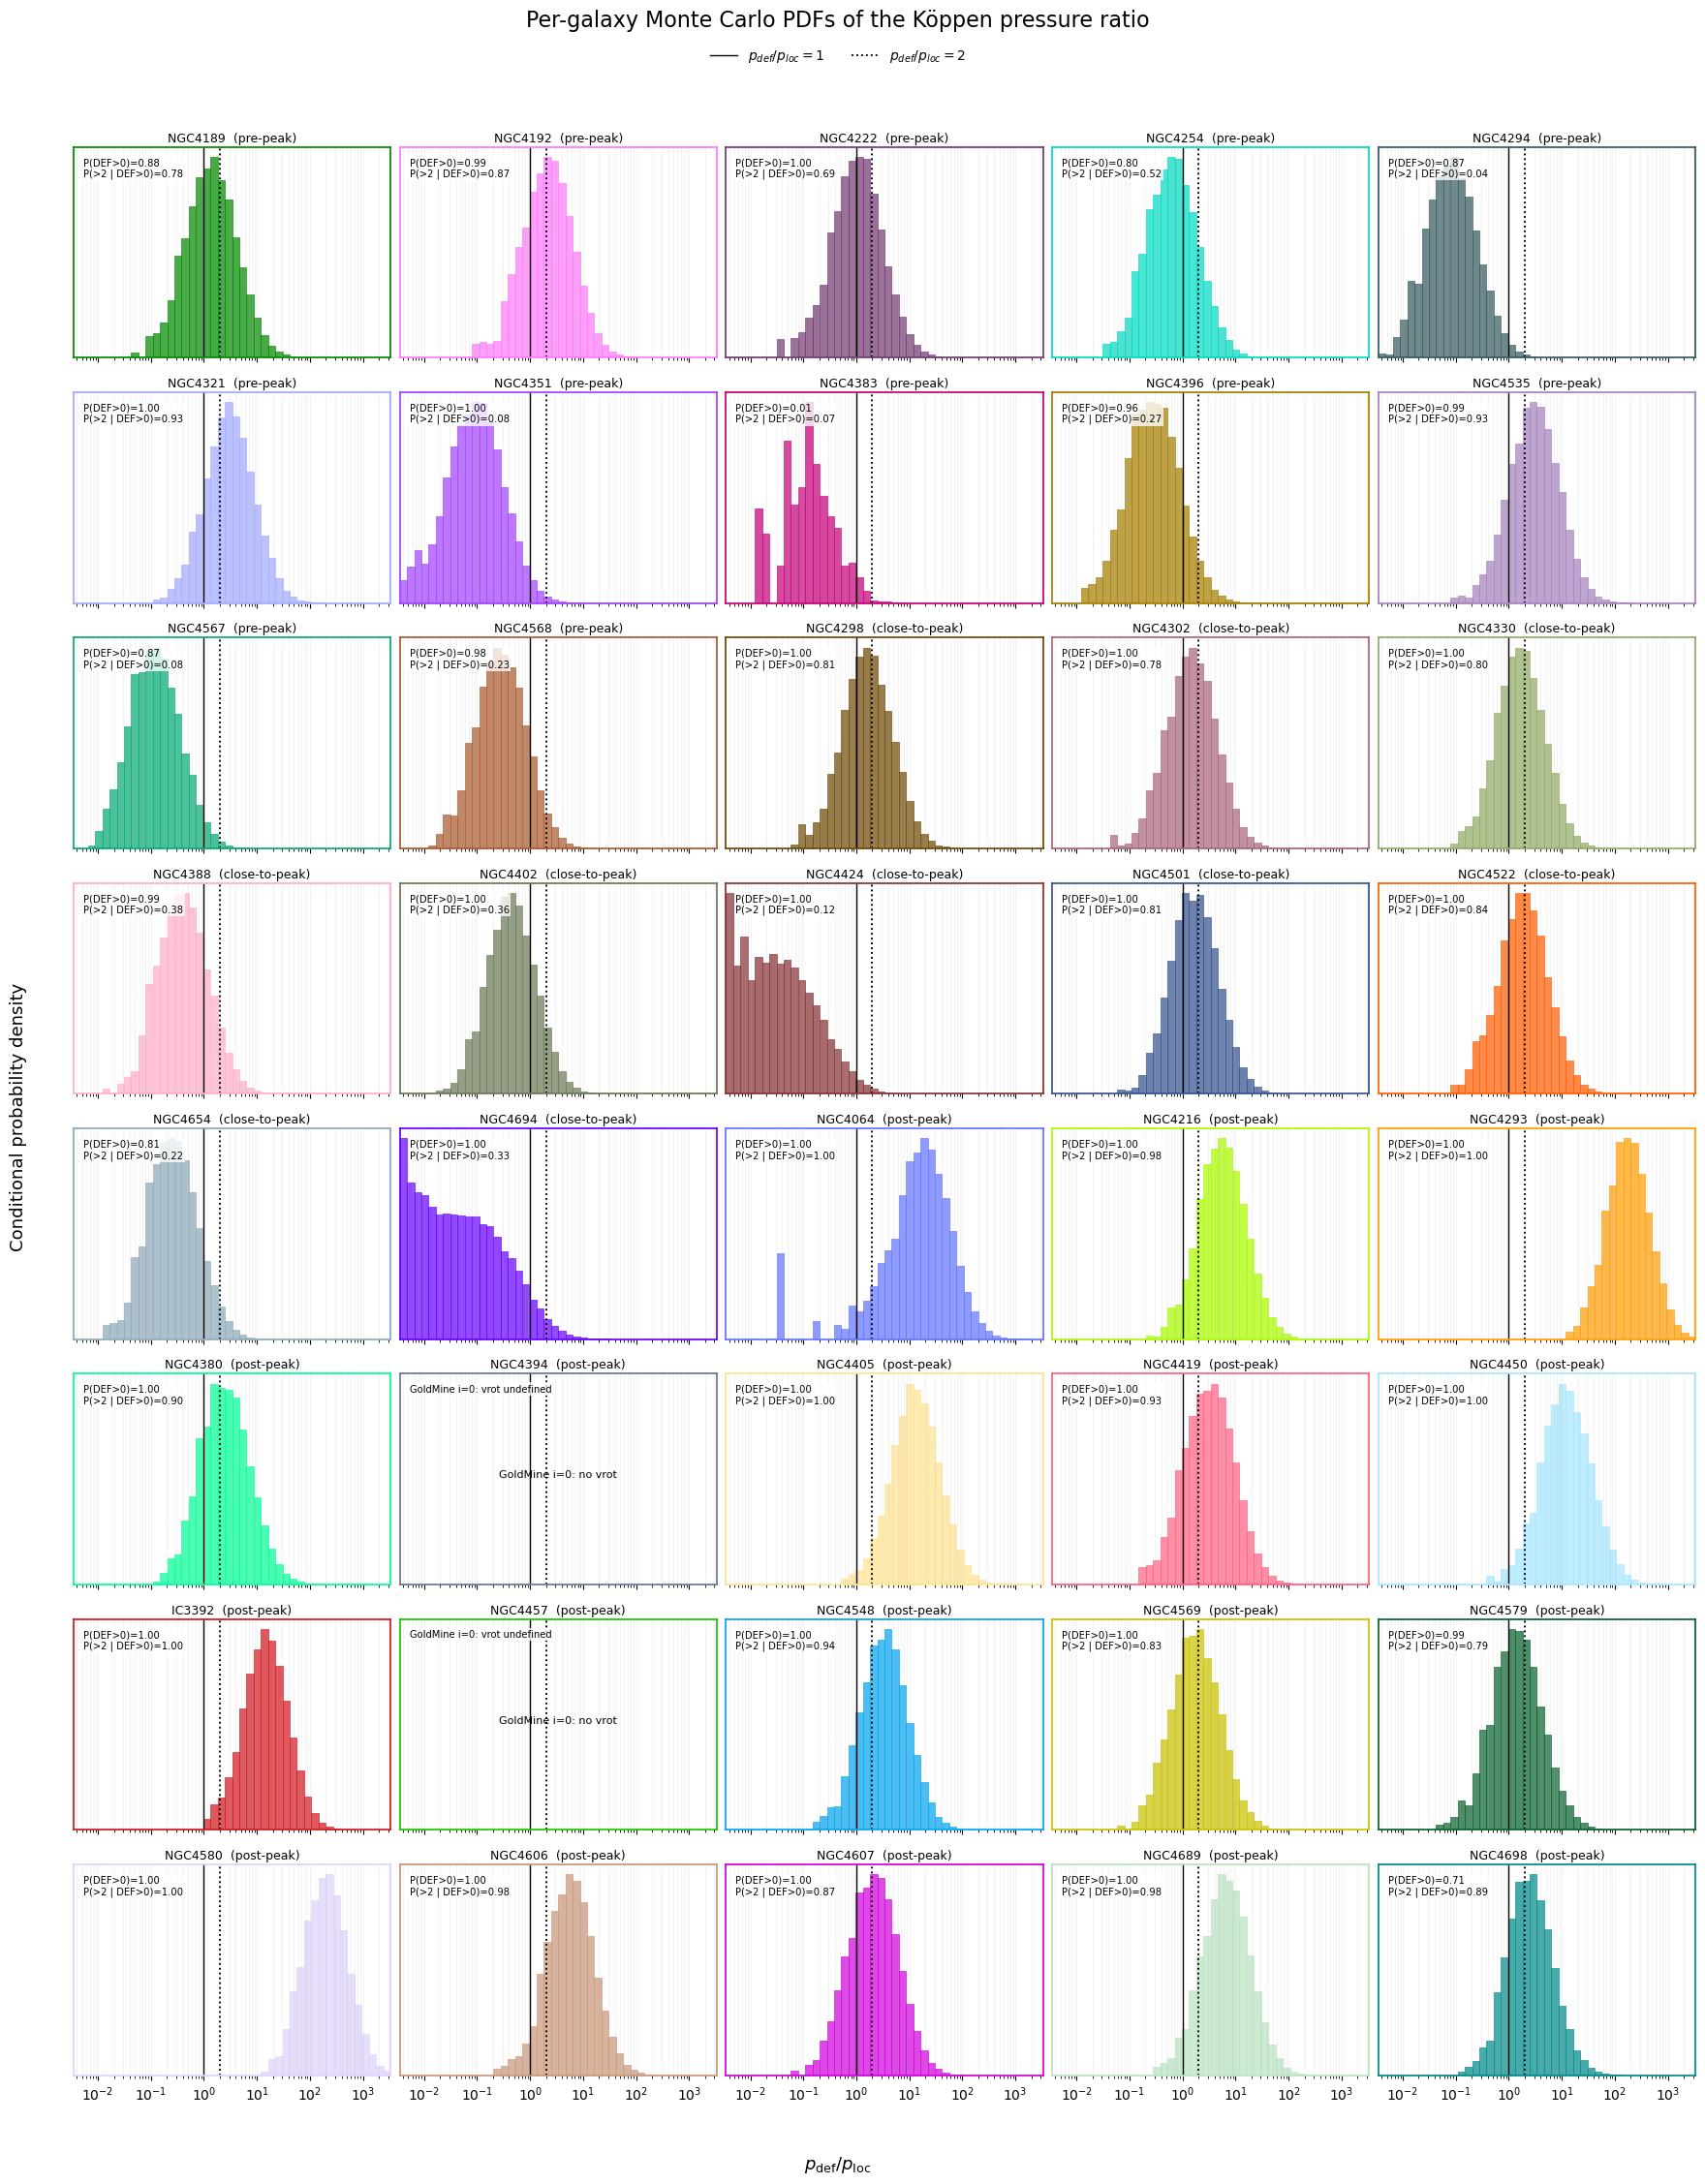

In [10]:
# Use common logarithmic bins so all 40 panels are directly comparable.
all_ratio_values = np.concatenate([values for values in ratio_draws.values() if len(values) > 0])
x_min = min(0.25, np.percentile(all_ratio_values, 0.1))
x_max = max(4.0, np.percentile(all_ratio_values, 99.9))
ratio_bins = np.geomspace(x_min, x_max, 45)

fig, axes = plt.subplots(8, 5, figsize=(18, 23), sharex=True)
axes = axes.ravel()

for ax, row in zip(axes, results.itertuples(index=False)):
    values = ratio_draws[row.Galaxy]
    if len(values) > 0:
        ax.hist(
            values,
            bins=ratio_bins,
            density=True,
            color=row.galaxy_color,
            alpha=0.72,
            edgecolor=row.galaxy_color,
            linewidth=0.6,
        )
    else:
        message = "GoldMine i=0: no vrot" if not np.isfinite(row.vrot) else "No positive-DEF draws"
        ax.text(0.5, 0.52, message, transform=ax.transAxes,
                ha="center", va="center", fontsize=8)

    ax.axvline(1.0, color="black", linewidth=1.0)
    ax.axvline(2.0, color="black", linestyle=":", linewidth=1.35)
    ax.set_xscale("log")
    ax.set_xlim(x_min, x_max)
    ax.set_yticks([])
    ax.grid(axis="x", which="both", alpha=0.15)
    ax.set_title(f"{row.Galaxy}  ({row.stage_label})", fontsize=9, pad=4)
    stats_text = (
        f"P(DEF>0)={row.P_DEF_positive:.2f}\n"
        f"P(>2 | DEF>0)={row.P_past_given_DEF_positive:.2f}"
        if np.isfinite(row.vrot) else "GoldMine i=0: vrot undefined"
    )
    ax.text(
        0.03, 0.95, stats_text,
        transform=ax.transAxes, ha="left", va="top", fontsize=7.2,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 1.2},
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(row.galaxy_color)
        spine.set_linewidth(1.25)

fig.supxlabel(r"$p_{\rm def}/p_{\rm loc}$", fontsize=13, y=0.025)
fig.supylabel("Conditional probability density", fontsize=13, x=0.025)
fig.suptitle(
    "Per-galaxy Monte Carlo PDFs of the Köppen pressure ratio",
    fontsize=16, y=0.997,
)
fig.legend(
    handles=[
        Line2D([], [], color="black", linewidth=1.0, label=r"$p_{def}/p_{loc}=1$"),
        Line2D([], [], color="black", linestyle=":", linewidth=1.35,
               label=r"$p_{def}/p_{loc}=2$"),
    ],
    loc="upper center", bbox_to_anchor=(0.5, 0.985), ncol=2, frameon=False,
)
fig.tight_layout(rect=(0.035, 0.035, 1.0, 0.965), h_pad=1.1, w_pad=0.7)
plt.show()

## 10. Main pressure-plane result

The left panel shows deterministic central $p_{\rm def}$ against central $p_{\rm loc}$. The added right panel shows the corresponding **central** ratio $p_{\rm def}/p_{\rm loc}$ galaxy by galaxy; it contains no Monte Carlo summaries. The solid and dotted reference lines mark ratios 1 and 2.

Galaxies with non-positive central deficiency have no physical deficiency-inverted stripping radius. NGC4394 and NGC4457 additionally lack a finite GoldMine rotation speed. All such rows are omitted from the pressure panels and named explicitly in the right-panel title and printed text.
Every finite central-value galaxy above the factor-of-two boundary $p_{\rm def}/p_{\rm loc}>2$ is annotated by name in the new central panel.


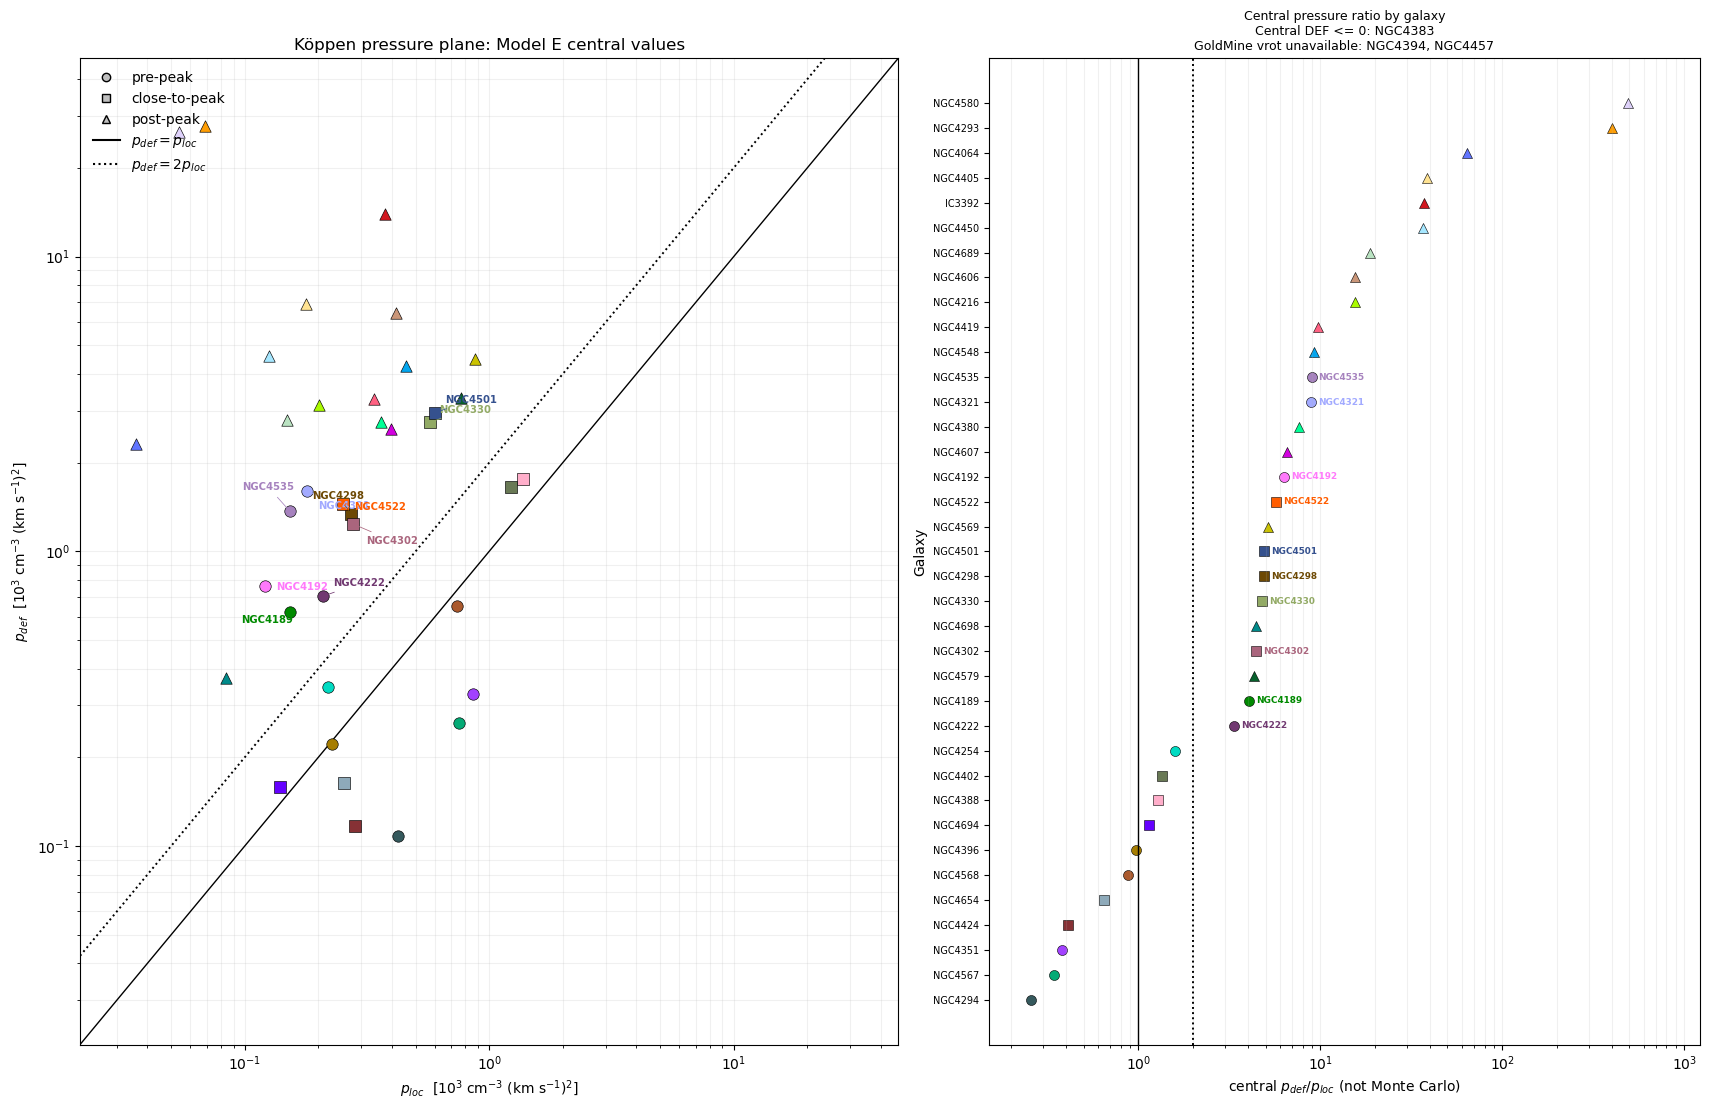

Central DEF <= 0 (not plotted in central-ratio panel): NGC4383
GoldMine vrot unavailable (not plotted): NGC4394, NGC4457
Pre-/close-to-peak galaxies with deterministic p_def/p_loc > 2: NGC4535, NGC4321, NGC4192, NGC4189, NGC4222, NGC4522, NGC4501, NGC4298, NGC4330, NGC4302


,Galaxy,stage_label,p_def,p_loc,pressure_ratio,Delta_RP
9,NGC4535,pre-peak,1.368,0.153,8.945,0.9516
5,NGC4321,pre-peak,1.599,0.1805,8.858,0.9474
1,NGC4192,pre-peak,0.7641,0.1206,6.335,0.8017
0,NGC4189,pre-peak,0.6242,0.1532,4.074,0.61
2,NGC4222,pre-peak,0.7045,0.2092,3.368,0.5274
19,NGC4522,close-to-peak,1.453,0.2531,5.741,0.759
18,NGC4501,close-to-peak,2.956,0.602,4.91,0.6911
12,NGC4298,close-to-peak,1.335,0.273,4.89,0.6893
14,NGC4330,close-to-peak,2.741,0.5721,4.791,0.6804
13,NGC4302,close-to-peak,1.237,0.2785,4.44,0.6474


Central-ratio pre-/close-to-peak galaxies above 2: NGC4189, NGC4192, NGC4222, NGC4321, NGC4535, NGC4298, NGC4302, NGC4330, NGC4501, NGC4522


In [11]:
# Cross-diagnostic tension: MAUVE pre-/close-to-peak but central ratio > 2.
results["deterministic_nonpost_ratio_gt2"] = (
    results["stage"].isin([1, 2])
    & np.isfinite(results["pressure_ratio"])
    & (results["pressure_ratio"] > 2.0)
)

pressure_label_offsets = {
    "NGC4535": (-34, 15), "NGC4189": (-35, -8),
    "NGC4321": (8, -13), "NGC4192": (8, -3),
    "NGC4298": (-28, 11), "NGC4501": (7, 7),
    "NGC4522": (8, -5), "NGC4302": (9, -14),
}
fig, (ax_plane, ax_ratio) = plt.subplots(
    1, 2, figsize=(17.2, 11.2), gridspec_kw={"width_ratios": [1.15, 1.0]}
)
finite = np.isfinite(results["p_def"]) & np.isfinite(results["p_loc"])

for _, row in results.loc[finite].iterrows():
    ax_plane.scatter(
        row["p_loc"], row["p_def"], s=68,
        marker=stage_markers[row["stage"]], color=row["galaxy_color"],
        edgecolor="black", linewidth=0.45, zorder=3,
    )
    if row["deterministic_nonpost_ratio_gt2"]:
        ax_plane.annotate(
            row["Galaxy"], (row["p_loc"], row["p_def"]),
            xytext=pressure_label_offsets.get(row["Galaxy"], (7, 7)),
            textcoords="offset points", fontsize=7.2, fontweight="bold",
            color=row["galaxy_color"],
            arrowprops={"arrowstyle": "-", "color": row["galaxy_color"], "lw": 0.55},
            zorder=4,
        )

lo = min(results.loc[finite, ["p_loc", "p_def"]].min()) / 1.7
hi = max(results.loc[finite, ["p_loc", "p_def"]].max()) * 1.7
grid = np.geomspace(lo, hi, 300)
ax_plane.plot(grid, grid, color="black", linewidth=1.0, label=r"$p_{def}=p_{loc}$")
ax_plane.plot(grid, 2.0 * grid, color="black", linestyle=":", linewidth=1.4,
              label=r"$p_{def}=2p_{loc}$")
ax_plane.set_xscale("log")
ax_plane.set_yscale("log")
ax_plane.set(xlim=(lo, hi), ylim=(lo, hi),
             xlabel=r"$p_{loc}$  [$10^3$ cm$^{-3}$ (km s$^{-1}$)$^2$]",
             ylabel=r"$p_{def}$  [$10^3$ cm$^{-3}$ (km s$^{-1}$)$^2$]")
ax_plane.grid(which="both", alpha=0.18)
handles = [Line2D([], [], marker=stage_markers[s], linestyle="None", color="0.35",
                  markerfacecolor="0.75", markeredgecolor="black", label=stage_labels[s])
           for s in (1, 2, 3)]
handles += [Line2D([], [], color="black", label=r"$p_{def}=p_{loc}$"),
            Line2D([], [], color="black", linestyle=":", label=r"$p_{def}=2p_{loc}$")]
ax_plane.legend(handles=handles, frameon=False, loc="upper left")
ax_plane.set_title("Köppen pressure plane: Model E central values")

# Added central-value ratio panel. It contains no Monte Carlo summaries.
central_valid = np.isfinite(results["pressure_ratio"]) & (results["pressure_ratio"] > 0)
central_ranked = results.loc[central_valid].sort_values("pressure_ratio").reset_index(drop=True)
ypos = np.arange(len(central_ranked))
for y, (_, row) in zip(ypos, central_ranked.iterrows()):
    ax_ratio.scatter(
        row["pressure_ratio"], y, s=52, color=row["galaxy_color"],
        marker=stage_markers[row["stage"]], edgecolor="black", linewidth=0.4,
    )
    if row["stage"] in (1, 2) and row["pressure_ratio"] > 2.0:
        ax_ratio.annotate(
            row["Galaxy"], (row["pressure_ratio"], y),
            xytext=(5, 0), textcoords="offset points", ha="left", va="center",
            fontsize=6.4, fontweight="bold", color=row["galaxy_color"],
        )
ax_ratio.set_xlim(
    central_ranked["pressure_ratio"].min() / 1.7,
    central_ranked["pressure_ratio"].max() * 2.5,
)
ax_ratio.axvline(1.0, color="black", linewidth=1.0)
ax_ratio.axvline(2.0, color="black", linestyle=":", linewidth=1.4)
ax_ratio.set_xscale("log")
ax_ratio.set_yticks(ypos, central_ranked["Galaxy"], fontsize=7)
ax_ratio.set_xlabel(r"central $p_{def}/p_{loc}$ (not Monte Carlo)")
ax_ratio.set_ylabel("Galaxy")
ax_ratio.grid(axis="x", which="both", alpha=0.18)
negative_central_names = results.loc[results["DEF"] <= 0, "Galaxy"].tolist()
missing_vrot_names = results.loc[~np.isfinite(results["vrot"]), "Galaxy"].tolist()
ax_ratio.set_title(
    "Central pressure ratio by galaxy\n"
    + "Central DEF <= 0: " + ", ".join(negative_central_names)
    + "\nGoldMine vrot unavailable: " + ", ".join(missing_vrot_names),
    fontsize=9,
)
fig.tight_layout()
plt.show()
print("Central DEF <= 0 (not plotted in central-ratio panel): " + ", ".join(negative_central_names))
print("GoldMine vrot unavailable (not plotted): " + ", ".join(missing_vrot_names))

deterministic_stage_tension = (
    results.loc[results["deterministic_nonpost_ratio_gt2"]]
    .sort_values(["stage", "pressure_ratio"], ascending=[True, False])
    [["Galaxy", "stage_label", "p_def", "p_loc", "pressure_ratio", "Delta_RP"]]
)
print(
    "Pre-/close-to-peak galaxies with deterministic p_def/p_loc > 2: "
    + ", ".join(deterministic_stage_tension["Galaxy"])
)
display(deterministic_stage_tension)
central_nonpost_gt2_names = results.loc[
    central_valid & results["stage"].isin([1, 2]) & (results["pressure_ratio"] > 2.0),
    "Galaxy",
].tolist()
print("Central-ratio pre-/close-to-peak galaxies above 2: " + ", ".join(central_nonpost_gt2_names))


## 11. Stage comparison: Monte Carlo and central values

The left panel shows the Monte Carlo median $\Delta_{\rm RP}$ with its 16th–84th percentile interval. The added right panel recomputes the stage comparison from the deterministic central $p_{\rm def}/p_{\rm loc}$ values only.

Central non-positive-deficiency galaxies and the two inclination-zero GoldMine rows are excluded from the right-panel points and named in its text box. Any existing Monte Carlo label selection is retained independently of the new central-value panel.
Every finite central-value galaxy above the factor-of-two boundary $p_{\rm def}/p_{\rm loc}>2$ is annotated by name in the new central panel.


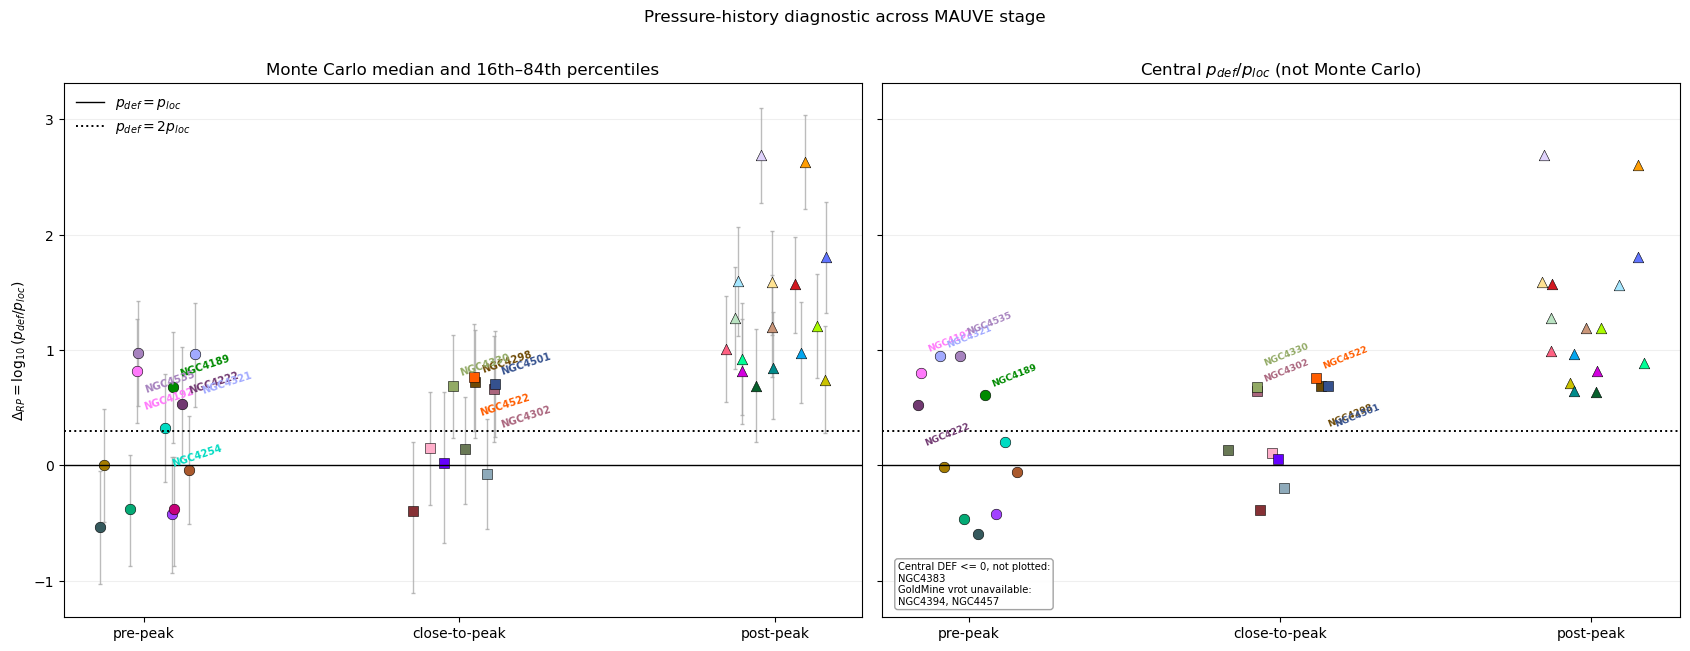

Pre-/close-to-peak galaxies satisfying the displayed MC selection: NGC4535, NGC4321, NGC4192, NGC4189, NGC4222, NGC4254, NGC4522, NGC4298, NGC4501, NGC4330, NGC4302


,Galaxy,stage_label,ratio_p16,ratio_p50,ratio_p84,P_DEF_positive,P_past_given_DEF_positive
9,NGC4535,pre-peak,3.246,9.379,26.84,0.992,0.9267
5,NGC4321,pre-peak,3.187,9.203,25.57,0.9984,0.9263
1,NGC4192,pre-peak,2.337,6.65,18.63,0.9935,0.8742
0,NGC4189,pre-peak,1.562,4.773,14.27,0.8758,0.7801
2,NGC4222,pre-peak,1.156,3.439,10.59,0.998,0.689
3,NGC4254,pre-peak,0.7125,2.127,6.206,0.8009,0.5231
19,NGC4522,close-to-peak,2.007,5.829,16.85,1,0.8408
12,NGC4298,close-to-peak,1.745,5.235,14.83,0.9988,0.8078
18,NGC4501,close-to-peak,1.762,5.04,14.63,0.9991,0.8087
14,NGC4330,close-to-peak,1.736,4.92,13.5,1,0.804


Central-ratio pre-/close-to-peak galaxies above 2: NGC4189, NGC4192, NGC4222, NGC4321, NGC4535, NGC4298, NGC4302, NGC4330, NGC4501, NGC4522


In [12]:
# Label pre-/close-to-peak Monte Carlo medians above the factor-of-two line.
results["mc_median_nonpost_ratio_gt2"] = (
    results["stage"].isin([1, 2])
    & np.isfinite(results["ratio_p50"])
    & (results["ratio_p50"] > 2.0)
)

fig, (ax_mc, ax_central) = plt.subplots(1, 2, figsize=(17.0, 6.4), sharey=True)
jitter_rng = np.random.default_rng(42)

for stage in (1, 2, 3):
    group = results[(results["stage"] == stage) & np.isfinite(results["Delta_RP_p50"])]
    x = stage + jitter_rng.uniform(-0.17, 0.17, len(group))
    y = group["Delta_RP_p50"].to_numpy()
    yerr = np.vstack([
        y - group["Delta_RP_p16"].to_numpy(),
        group["Delta_RP_p84"].to_numpy() - y,
    ])
    ax_mc.errorbar(x, y, yerr=yerr, fmt="none", ecolor="0.65", alpha=0.75,
                   elinewidth=1.0, capsize=1.5, zorder=1)
    for label_number, (xpos, (_, row)) in enumerate(zip(x, group.iterrows())):
        ax_mc.scatter(xpos, row["Delta_RP_p50"], s=58, color=row["galaxy_color"],
                      marker=stage_markers[stage], edgecolor="black", linewidth=0.4, zorder=2)
        if row["mc_median_nonpost_ratio_gt2"]:
            y_offset = 6 if label_number % 2 == 0 else -11
            ax_mc.annotate(
                row["Galaxy"], (xpos, row["Delta_RP_p50"]),
                xytext=(4, y_offset), textcoords="offset points",
                fontsize=7.2, fontweight="bold", color=row["galaxy_color"],
                rotation=18, ha="left", va="bottom" if y_offset > 0 else "top",
                zorder=3,
            )

ax_mc.axhline(0.0, color="black", linewidth=1.0, label=r"$p_{def}=p_{loc}$")
ax_mc.axhline(np.log10(2.0), color="black", linestyle=":", linewidth=1.4,
              label=r"$p_{def}=2p_{loc}$")
ax_mc.set_xticks([1, 2, 3], [stage_labels[s] for s in (1, 2, 3)])
ax_mc.set_ylabel(r"$\Delta_{RP}=\log_{10}(p_{def}/p_{loc})$")
ax_mc.set_title("Monte Carlo median and 16th–84th percentiles")
ax_mc.grid(axis="y", alpha=0.2)
ax_mc.legend(frameon=False)

# Added central-value stage panel. Negative/non-positive central deficiencies
# are deliberately absent because their stripping-radius inversion is undefined.
central_stage_valid = np.isfinite(results["pressure_ratio"]) & (results["pressure_ratio"] > 0)
central_jitter_rng = np.random.default_rng(43)
central_label_number = 0
for stage in (1, 2, 3):
    group = results[(results["stage"] == stage) & central_stage_valid]
    x = stage + central_jitter_rng.uniform(-0.17, 0.17, len(group))
    for xpos, (_, row) in zip(x, group.iterrows()):
        central_y = np.log10(row["pressure_ratio"])
        ax_central.scatter(
            xpos, central_y, s=58,
            color=row["galaxy_color"], marker=stage_markers[stage],
            edgecolor="black", linewidth=0.4,
        )
        if stage in (1, 2) and row["pressure_ratio"] > 2.0:
            label_offsets = [(4, 5), (4, 14), (4, -12)]
            offset = label_offsets[central_label_number % len(label_offsets)]
            ax_central.annotate(
                row["Galaxy"], (xpos, central_y), xytext=offset,
                textcoords="offset points", fontsize=6.6, fontweight="bold",
                color=row["galaxy_color"], rotation=22, ha="left",
                va="bottom" if offset[1] >= 0 else "top", zorder=3,
            )
            central_label_number += 1
ax_central.axhline(0.0, color="black", linewidth=1.0)
ax_central.axhline(np.log10(2.0), color="black", linestyle=":", linewidth=1.4)
ax_central.set_xticks([1, 2, 3], [stage_labels[s] for s in (1, 2, 3)])
ax_central.set_title("Central $p_{def}/p_{loc}$ (not Monte Carlo)")
ax_central.grid(axis="y", alpha=0.2)
negative_central_names = results.loc[results["DEF"] <= 0, "Galaxy"].tolist()
missing_vrot_names = results.loc[~np.isfinite(results["vrot"]), "Galaxy"].tolist()
ax_central.text(
    0.02, 0.02,
    "Central DEF <= 0, not plotted:\n" + ", ".join(negative_central_names)
    + "\nGoldMine vrot unavailable:\n" + ", ".join(missing_vrot_names),
    transform=ax_central.transAxes, ha="left", va="bottom", fontsize=7.2,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "0.6", "alpha": 0.9},
)
fig.suptitle("Pressure-history diagnostic across MAUVE stage", y=1.01)
fig.tight_layout()
plt.show()

mc_stage_tension = (
    results.loc[results["mc_median_nonpost_ratio_gt2"]]
    .sort_values(["stage", "ratio_p50"], ascending=[True, False])
    [["Galaxy", "stage_label", "ratio_p16", "ratio_p50", "ratio_p84",
      "P_DEF_positive", "P_past_given_DEF_positive"]]
)
print(
    "Pre-/close-to-peak galaxies satisfying the displayed MC selection: "
    + ", ".join(mc_stage_tension["Galaxy"])
)
display(mc_stage_tension)
central_nonpost_gt2_names = results.loc[
    central_valid & results["stage"].isin([1, 2]) & (results["pressure_ratio"] > 2.0),
    "Galaxy",
].tolist()
print("Central-ratio pre-/close-to-peak galaxies above 2: " + ", ".join(central_nonpost_gt2_names))


## 12. Stage summaries and calibration sensitivity

Because the sample is modest and several uncertainties are shared systematics, the table reports robust descriptive summaries rather than a formal stage-sequence significance test. The second table asks how much the central deficiency changes if the AMIGA all-type fit is used instead of the fiducial morphology-dependent fit.

In [13]:
stage_summary = (
    results.groupby(["stage", "stage_label"], observed=True)
    .agg(
        N=("Galaxy", "size"),
        median_DEF=("DEF_p50", "median"),
        median_Delta_RP=("Delta_RP_p50", "median"),
        median_P_DEF_positive=("P_DEF_positive", "median"),
        median_P_past_given_positive=("P_past_given_DEF_positive", "median"),
        N_past_favoured=("MC_interpretation", lambda x: (x == "past-stripping favoured").sum()),
        N_ambiguous=("MC_interpretation", lambda x: (x == "ambiguous").sum()),
        N_ongoing_compatible=("MC_interpretation", lambda x: (x == "ongoing-compatible").sum()),
        N_mostly_nondeficient=("MC_interpretation", lambda x: (x == "mostly non-deficient / inversion unstable").sum()),
        N_no_GoldMine_vrot=("MC_interpretation", lambda x: (x == "GoldMine inclination=0: no vrot").sum()),
    )
    .reset_index()
)
display(stage_summary)

calibration_check = results[["Galaxy", "stage_label", "DEF", "DEF_all"]].copy()
calibration_check["DEF_all_minus_fiducial"] = calibration_check["DEF_all"] - calibration_check["DEF"]
display(calibration_check.sort_values("DEF_all_minus_fiducial", key=np.abs, ascending=False))
print("Median |DEF_all - DEF_fiducial| = "
      f"{np.median(np.abs(calibration_check['DEF_all_minus_fiducial'])):.3f} dex")

,stage,stage_label,N,median_DEF,median_Delta_RP,median_P_DEF_positive,median_P_past_given_positive,N_past_favoured,N_ambiguous,N_ongoing_compatible,N_mostly_nondeficient,N_no_GoldMine_vrot
0,1,pre-peak,12,0.4678,0.1639,0.9721,0.3953,3,5,3,1,0
1,2,close-to-peak,10,0.8125,0.4079,0.9992,0.5807,1,8,1,0,0
2,3,post-peak,18,1.158,1.206,1,0.9788,14,2,0,0,2


,Galaxy,stage_label,DEF,DEF_all,DEF_all_minus_fiducial
7,NGC4383,pre-peak,-0.7717,-0.3064,0.4654
28,NGC4419,post-peak,1.204,1.622,0.418
25,NGC4380,post-peak,0.8644,1.282,0.418
17,NGC4424,close-to-peak,0.8699,1.256,0.3856
22,NGC4064,post-peak,1.611,1.987,0.3758
24,NGC4293,post-peak,1.878,2.238,0.36
36,NGC4606,post-peak,1.909,2.269,0.36
15,NGC4388,close-to-peak,0.7362,1.096,0.36
39,NGC4698,post-peak,0.1835,0.5269,0.3435
29,NGC4450,post-peak,1.017,1.347,0.3308


Median |DEF_all - DEF_fiducial| = 0.054 dex


## 13. Automated QC and interpretation guardrails

These checks distinguish a notebook that merely ran from one whose key scientific joins and outputs are internally coherent.

- Every physical component must appear exactly once with finite GoldMine $D_{25}$ and morphology information.
- The GoldMine line-width/inclination conversion must reproduce every live derived $v_{\rm rot}$; the only undefined velocities must be NGC4394 and NGC4457.
- NGC4064 must remain visibly marked as a published GoldMine/Köppen reconstruction, and NGC4694 must remain the sole Jones all-type fallback.
- All deterministic Wang cutoffs and local-pressure inputs must be finite and positive.
- A positive central DEF must produce a stripping radius; pressure additionally requires a finite GoldMine rotation speed.
- Monte Carlo probabilities must stay in $[0,1]$, with pressure probabilities undefined only for the two inclination-zero galaxies.
- The published $p_{\rm loc}$ regression must remain within its tolerance, and all three MAUVE stages must remain present.

Passing these checks validates the implementation and bookkeeping. It does **not** remove the stated catalogue-provenance, morphology-mapping, projection, or model-systematic limitations.

In [14]:
assert len(results) == 40 and results["Galaxy"].nunique() == 40
assert set(results["stage"]) == {1, 2, 3}
assert results[[
    "D25_arcsec", "D25_kpc", "Ropt_kpc", "goldmine_type_code",
    "DHI0_Wang_kpc", "rmax_kpc", "Rproj_mpc", "p_loc",
]].notna().all().all()
assert (results[["D25_arcsec", "D25_kpc", "Ropt_kpc", "DHI0_Wang_kpc", "rmax_kpc", "v_esc_kms", "v_upper_kms", "p_loc"]] > 0).all().all()

pressure_ready = np.isfinite(results["vrot"])
assert pressure_ready.sum() == 38
assert set(results.loc[~pressure_ready, "Galaxy"]) == {"NGC4394", "NGC4457"}
assert np.allclose(results.loc[pressure_ready, "vrot_uncertainty_kms"], SIGMA_VROT_KMS)
live_width_rows = (
    np.isfinite(results["inclination_deg"])
    & (results["inclination_deg"] > 0)
    & np.isfinite(results["WIDTHA_kms"])
)
expected_live_vrot = (
    0.98 * results.loc[live_width_rows, "WIDTHA_kms"]
    / (2.0 * np.sin(np.deg2rad(results.loc[live_width_rows, "inclination_deg"])))
)
assert np.allclose(results.loc[live_width_rows, "vrot"], expected_live_vrot)
assert results.loc[results["Galaxy"] == "NGC4064", "input_status"].str.contains("Koppen2018 Appendix E").all()
assert set(results.loc[results["goldmine_type_code"] == 20, "Galaxy"]) == {"NGC4694"}
assert results.loc[results["Galaxy"] == "NGC4694", "amiga_relation_source"].str.contains("all-type fallback").all()

assert np.allclose(results["v_upper_kms"], np.maximum(results["v_esc_kms"], results["v_relative_los_kms"]))
assert (results["p_loc"] >= results["p_loc_escape_only"] - 1e-12).all()

positive_def = results["DEF"] > 0
assert results.loc[positive_def, "r_strip_kpc"].notna().all()
assert results.loc[~positive_def, ["r_strip_kpc", "p_def", "pressure_ratio"]].isna().all().all()
pressure_inversion = pressure_ready & positive_def
assert results.loc[pressure_inversion, ["p_def", "pressure_ratio"]].notna().all().all()
assert results.loc[~pressure_ready, ["p_def", "pressure_ratio"]].isna().all().all()

assert results["P_DEF_positive"].between(0.0, 1.0).all()
for column in ["P_past_joint", "P_past_given_DEF_positive"]:
    finite_probability = results[column].dropna()
    assert finite_probability.between(0.0, 1.0).all(), f"Invalid probability in {column}"
    assert set(results.loc[results[column].isna(), "Galaxy"]) == {"NGC4394", "NGC4457"}
assert (results.loc[pressure_ready, "P_past_joint"] <= results.loc[pressure_ready, "P_DEF_positive"] + 1e-12).all()
assert np.median(np.abs(paper_ploc["fractional_residual"])) < 0.10

print("All strict Model-E QC checks passed.")
print(f"Central-input positive DEF: {positive_def.sum()}/40")
print("Pressure-ready GoldMine rows: 38/40")
print("Monte Carlo interpretation counts:")
display(results["MC_interpretation"].value_counts().rename_axis("interpretation").to_frame("N"))

All strict Model-E QC checks passed.
Central-input positive DEF: 39/40
Pressure-ready GoldMine rows: 38/40
Monte Carlo interpretation counts:


,N
interpretation,
past-stripping favoured,18
ambiguous,15
ongoing-compatible,4
GoldMine inclination=0: no vrot,2
mostly non-deficient / inversion unstable,1


## 14. How to read and extend this notebook

### What is ready to use

- A complete 40-galaxy table with GoldMine optical diameters/morphologies, Jones-AMIGA initial H I masses, and Wang initial H I cutoffs.
- Deterministic and Monte Carlo DEF/radius outputs for all 40 galaxies.
- Pressure diagnostics for the 38 galaxies with finite GoldMine inclination-corrected rotation speed.
- Stage-level plots, summaries, a fixed galaxy palette, and the same local-pressure calculation as Model C.
- Explicit provenance flags for the NGC4064 reconstruction and NGC4694 all-type fallback.

### Limitations that must travel with any result

1. **Observed H I provenance:** `logMHI` is still taken from the local MAUVE master compilation, whose per-row survey origin and uncertainty are not stored in the file. The 0.10 dex error remains a provisional floor.
2. **NGC4064 GoldMine reconstruction:** the current GoldMine endpoint returns a placeholder at this position. Model E reconstructs $D_{25}$ from the published GoldMine-derived Köppen $R_{\rm opt}=11.4$ kpc at 17 Mpc, retains the published $v_{\rm rot}=58.8$ km s$^{-1}$, and maps the SB(s)a morphology to GoldMine's Sa code 3.
3. **GoldMine morphology:** code 20 leaves NGC4694 unclassified. Its fiducial expected H I mass therefore uses the Jones all-type relation rather than pretending that GoldMine supplied a morphology bin.
4. **Inclination-zero velocities:** NGC4394 and NGC4457 have GoldMine `WIDTHA` but $i=0^\circ$, so $v_{\rm rot}\propto1/\sin i$ and all pressure outputs are undefined. Their DEF and H I-size calculations remain available.
5. **GoldMine uncertainty model:** 0.08 dex in optical size and 15 km s$^{-1}$ in rotation speed are empirical cross-catalogue scatters, not row-level likelihoods. GoldMine morphology is held fixed.
6. **Projected radius and velocity:** $R_{\rm proj}$ remains a lower limit to 3D radius, and the maximum of escape speed and LOS difference is a conservative comparison speed rather than a strict upper limit for every orbit.
7. **Shared systematics:** AMIGA/Wang coefficients, common distance, ICM model, and halo model induce correlated uncertainties. The current Monte Carlo samples relation scatters independently per galaxy.
8. **Interpretation labels:** the 0.16/0.84 probability labels are reporting conventions. The continuous ratio and probability columns remain the primary outputs.

### Recommended next steps

1. Recover or independently verify the historical GoldMine NGC4064 row and its exact morphology code.
2. Add external inclinations or resolved rotation speeds for NGC4394 and NGC4457 only in a clearly labelled hybrid sensitivity model.
3. Compare GoldMine rotation speeds with resolved VIVA/VERTICO kinematics.
4. Recompute with shared nuisance draws for the AMIGA/Wang coefficients and Virgo ICM/halo parameters before population inference.
5. Compare Model E directly with Model C to isolate the HyperLeda-versus-GoldMine input systematic.

In [15]:
# Compact ranked table for immediate follow-up. Sorting by the conditional past
# probability does not hide the separate probability of positive deficiency.
ranked = results[[
    "Galaxy", "stage_label", "DEF_p50", "rmax_p50", "P_DEF_positive",
    "ratio_p50", "P_past_given_DEF_positive", "P_past_joint",
    "MC_interpretation", "amiga_relation_source", "goldmine_applicability_note",
]].sort_values(
    ["P_past_given_DEF_positive", "P_DEF_positive"],
    ascending=False,
    na_position="last",
)
display(ranked)

# Explicit cross-diagnostic list requested for manuscript/QC follow-up. The
# union retains galaxies flagged by either the deterministic ratio or the MC
# median and shows both criteria side-by-side.
nonpost_ratio_gt2 = (
    results.loc[
        results["deterministic_nonpost_ratio_gt2"] | results["mc_median_nonpost_ratio_gt2"]
    ]
    .sort_values(["stage", "ratio_p50"], ascending=[True, False])
    [["Galaxy", "stage_label", "pressure_ratio", "ratio_p16", "ratio_p50", "ratio_p84",
      "P_DEF_positive", "P_past_given_DEF_positive",
      "deterministic_nonpost_ratio_gt2", "mc_median_nonpost_ratio_gt2"]]
)

display(Markdown(
    "### Pre-/close-to-peak galaxies above the factor-of-two boundary\n"
    "The deterministic and Monte Carlo-median flags are shown separately because "
    "they answer slightly different questions."
))
display(nonpost_ratio_gt2)

display(Markdown("### GoldMine records without an inclination-corrected rotation speed"))
display(results.loc[~np.isfinite(results["vrot"]), [
    "Galaxy", "stage_label", "D25_kpc", "goldmine_type_code", "inclination_deg",
    "WIDTHA_kms", "P_DEF_positive", "input_status",
]])

display(Markdown("### GoldMine unclassified morphology using the Jones all-type fallback"))
display(results.loc[results["goldmine_type_code"] == 20, [
    "Galaxy", "stage_label", "D25_kpc", "goldmine_type_code", "logMHI_exp",
    "DEF", "amiga_relation_source",
]])

display(Markdown(
    "**Take-home rule:** use `ratio_p50` and its interval for the 38 pressure-ready "
    "galaxies; retain `P_DEF_positive` for all 40; treat the two inclination-zero rows "
    "as missing pressure constraints; and keep the NGC4064 reconstruction and NGC4694 "
    "all-type fallback attached to any object-level interpretation."
))

,Galaxy,stage_label,DEF_p50,rmax_p50,P_DEF_positive,ratio_p50,P_past_given_DEF_positive,P_past_joint,MC_interpretation,amiga_relation_source,goldmine_applicability_note
24,NGC4293,post-peak,1.88,13.44,1,425.4,1,1,past-stripping favoured,GoldMine E/S0-Sab -> Jones T<3,GoldMine morphology-bin mapping
35,NGC4580,post-peak,1.559,9.444,1,491.3,1,1,past-stripping favoured,GoldMine Sb-Sc -> Jones 3<=T<=5,GoldMine morphology-bin mapping
30,IC3392,post-peak,1.604,12.5,1,37.06,0.9983,0.9983,past-stripping favoured,GoldMine Sb-Sc -> Jones 3<=T<=5,GoldMine morphology-bin mapping
22,NGC4064,post-peak,1.608,12,1,64.56,0.9974,0.9974,past-stripping favoured,GoldMine E/S0-Sab -> Jones T<3,current GoldMine endpoint missing; K18 GoldMin...
27,NGC4405,post-peak,1.238,8.304,1,38.53,0.9974,0.9974,past-stripping favoured,GoldMine Sb-Sc -> Jones 3<=T<=5,GoldMine morphology-bin mapping
29,NGC4450,post-peak,1.021,16.38,0.9989,39.54,0.9968,0.9957,past-stripping favoured,GoldMine E/S0-Sab -> Jones T<3,GoldMine morphology-bin mapping
38,NGC4689,post-peak,1.135,24.14,1,18.91,0.9842,0.9842,past-stripping favoured,GoldMine Sb-Sc -> Jones 3<=T<=5,GoldMine morphology-bin mapping
23,NGC4216,post-peak,0.9184,36.72,0.9999,16.27,0.9789,0.9788,past-stripping favoured,GoldMine Sb-Sc -> Jones 3<=T<=5,GoldMine morphology-bin mapping
36,NGC4606,post-peak,1.911,13.43,1,15.87,0.9787,0.9787,past-stripping favoured,GoldMine E/S0-Sab -> Jones T<3,GoldMine morphology-bin mapping
32,NGC4548,post-peak,1.019,24.68,1,9.508,0.9351,0.9351,past-stripping favoured,GoldMine Sb-Sc -> Jones 3<=T<=5,GoldMine morphology-bin mapping


### Pre-/close-to-peak galaxies above the factor-of-two boundary
The deterministic and Monte Carlo-median flags are shown separately because they answer slightly different questions.

,Galaxy,stage_label,pressure_ratio,ratio_p16,ratio_p50,ratio_p84,P_DEF_positive,P_past_given_DEF_positive,deterministic_nonpost_ratio_gt2,mc_median_nonpost_ratio_gt2
9,NGC4535,pre-peak,8.945,3.246,9.379,26.84,0.992,0.9267,True,True
5,NGC4321,pre-peak,8.858,3.187,9.203,25.57,0.9984,0.9263,True,True
1,NGC4192,pre-peak,6.335,2.337,6.65,18.63,0.9935,0.8742,True,True
0,NGC4189,pre-peak,4.074,1.562,4.773,14.27,0.8758,0.7801,True,True
2,NGC4222,pre-peak,3.368,1.156,3.439,10.59,0.998,0.689,True,True
3,NGC4254,pre-peak,1.583,0.7125,2.127,6.206,0.8009,0.5231,False,True
19,NGC4522,close-to-peak,5.741,2.007,5.829,16.85,1,0.8408,True,True
12,NGC4298,close-to-peak,4.89,1.745,5.235,14.83,0.9988,0.8078,True,True
18,NGC4501,close-to-peak,4.91,1.762,5.04,14.63,0.9991,0.8087,True,True
14,NGC4330,close-to-peak,4.791,1.736,4.92,13.5,1,0.804,True,True


### GoldMine records without an inclination-corrected rotation speed

,Galaxy,stage_label,D25_kpc,goldmine_type_code,inclination_deg,WIDTHA_kms,P_DEF_positive,input_status
26,NGC4394,post-peak,17.28,5,0,174,0.9994,live GoldMine exact match; inclination=0 so vr...
31,NGC4457,post-peak,14.01,5,0,172,1,live GoldMine exact match; inclination=0 so vr...


### GoldMine unclassified morphology using the Jones all-type fallback

,Galaxy,stage_label,D25_kpc,goldmine_type_code,logMHI_exp,DEF,amiga_relation_source
21,NGC4694,close-to-peak,15.36,20,9.341,0.9112,GoldMine unclassified -> Jones all-type fallback


**Take-home rule:** use `ratio_p50` and its interval for the 38 pressure-ready galaxies; retain `P_DEF_positive` for all 40; treat the two inclination-zero rows as missing pressure constraints; and keep the NGC4064 reconstruction and NGC4694 all-type fallback attached to any object-level interpretation.